# Предсказание оттока

## Описание проекта

### Задача проекта

### Описание данных

Данные хранятся в двух файлах .xlsx. Имеются признаки:
- `№ брони` — уникальный номер бронирования;

...

In [1]:
# Будем решать задачу классификации, импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import phik
from phik.report import plot_correlation_matrix
import os

# Очистка оперативной памяти
import gc

# Нейронные сети
import torch
import torch.nn as nn
import skorch
from skorch.classifier import NeuralNetBinaryClassifier

# Модели на основе градиентного бустинга
from catboost import (CatBoostClassifier, cv as cb_cv, Pool)
from catboost.utils import get_roc_curve, select_threshold
from lightgbm import (LGBMClassifier, cv as lgbm_cv, plot_importance)

# Не будем ограничиваться нейронными сетями и градиентным бустингом.
# Попробуем более модель на основе случайного леса
from sklearn.ensemble import RandomForestClassifier

# Константная модель
from sklearn.dummy import DummyClassifier

# Разделение выборок, подбор гиперпараметров
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import (
    accuracy_score, # Расчёт accuracy
    roc_auc_score,  # Расчёт AUC ROC
    roc_curve,  # Построение ROC-кривой
    confusion_matrix  # Вычисление tn, fp, fn, tp
)

# Масштабирование и кодирования признаков
from sklearn.compose import make_column_transformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder, OrdinalEncoder)

# константы
RANDOM_STATE = 5
DATA_PATH_1 = ''
DATA_PATH_2 = '/content/drive/MyDrive/Colab Notebooks/psb_product/data/'
DOW_NUMBERS = {
        0:'Monday',
        1:'Tuesday',
        2:'Wednesday',
        3:'Thursday',
        4:'Friday',
        5:'Saturday',
        6:'Sunday'
    }
MONTH_NUMBERS = {
        1:'January',
        2:'February',
        3:'March',
        4:'April',
        5:'May',
        6:'June',
        7:'July',
        8:'August',
        9:'September',
        10:'October',
        11:'November',
        12:'December'
    }

## Вспомогательные функции

In [2]:
# Определим функцию, которая строит диаграмму размаха и гистограмму распределения
# значений определённого признака. Набор значений передаётся в качестве параметра
def show_feature_distribution(col: pd.Series) -> None:
    '''Принимает столбец со значениями, строит диаграмму размаха
    и гистограмму распределения значений'''
    fig, ax = plt.subplots(ncols=1, nrows=2,
                           figsize=(16, 6),
                           sharex=True,
                           gridspec_kw={'height_ratios': (.2, .8)})
    fig.suptitle(f'Диаграмма размаха и гистограмма распределения значений признака {col.name}', fontsize=14)
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['left'].set_visible(False)
    ax[0].tick_params(axis='y', left=False, labelleft=False)
    ax[1].grid(color='gray', linewidth = 0.5, linestyle = '--') 
    
    if type(col[0]) != pd._libs.tslibs.timestamps.Timestamp:
        # Определим шаг шкалы для оси x
        x_step = (col.max() - col.min()) / 20
        for step in [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2,
                     0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000,
                     2000, 5000, 1e4, 2e4, 5e4, 1e5]:
            if x_step / step < 1.5:
                x_step = step
                break
        x_min = x_step * int(col.min() / x_step)
        x_max = x_step * (1 + int(col.max() / x_step))
        ax[1].set_xticks(np.arange(x_min, x_max, x_step))
        ax[0].boxplot(col, vert=False, showmeans=True)
        ax[1].hist(col, bins=np.arange(x_min, x_max, x_step / 2))
    else:
        ax[0].spines['bottom'].set_visible(False)
        ax[1].hist(col)
    ax[1].set_xlabel(f'{col.name}')
    ax[1].set_ylabel('Количество объектов')       
    plt.show()

In [3]:
# Определим функцию для построения графиков. На вход подаётся таблица с данными
# по соотношению отменивших и не отменивших бронирование с группировкой по признаку
# Слева покажем количество отменивших бронирование, а справа - доли отменивших бронирование.
def show_factor(data, ax, factor_name, rotation=0):
    for ax_i in ax:
        ax_i.grid(color='gray', linewidth=0.5, linestyle='--', which='both')
        ax_i.set_xticks(range(len(data.index)))
        ax_i.set_xticklabels(data.index, rotation=rotation)
    ax[0].set_xlabel(factor_name, fontsize='small')
    ax[1].set_xlabel(factor_name, fontsize='small')
    ax[0].set_ylabel('Кол-во бронирований', fontsize='small')
    ax[1].set_ylabel('Доля бронирований', fontsize='small')
    x_axis = np.arange(data.shape[0])
    ax[0].bar(x_axis - 0.15, data['count'], width=0.3, label='Всего бронирований')
    ax[0].bar(
        x_axis + 0.15,
        data['sum'],
        width=0.3,
        color='red',
        label='Отменено бронирований',
        alpha=0.8
    )
    ax[0].legend()
    ax[1].bar(x_axis, data['mean'])
    ax[1].plot(
        [x_axis[0], x_axis[-1]],
        [average] * 2,
        color='red',
        label='В среднем по выборке',
        linestyle='--'
    )
    ax[1].legend()

In [4]:
# Определим функцию, которая из переданных ей двух датасетов и имени признака
# компонует таблицу с распределением значений признака в датасетах
def feature_count(train: pd.DataFrame,
                  test: pd.DataFrame,
                  feat_name: str) -> pd.DataFrame:
    '''Принимает два датасета, название исследуемого признака, 
    возвращает датафрейм с распределением количества объектов с тем или
    иным значением исследуемого признака в обоих датасетах'''
    result = train[feat_name].value_counts().reset_index().merge(
         train[feat_name].value_counts(normalize=True).reset_index(),
         how='outer', left_on=feat_name, right_on=feat_name).merge(
         test[feat_name].value_counts().reset_index().merge(
         test[feat_name].value_counts(normalize=True).reset_index(),
         how='outer', left_on=feat_name, right_on=feat_name),
         how='outer', left_on=feat_name, right_on=feat_name).fillna('')
    result.columns = ['Значение '+ feat_name, 'Частота в train', 'Доля в train',
                 'Частота в test', 'Доля в test']
    return result

In [5]:
# Определим функцию, которая строит график зависимости целевого
# признака от значений исследуемого
def show_target_dependence(dataset: pd.DataFrame,
                           factor: str,
                           target: str,
                           is_cat = True) -> None:
    '''Принимает датасет, название исследуемого и целевого признака, флаг
    категориальности исследуемого признака, строит график зависимости целевого
    признака от значений исследуемого'''
    df = dataset[[factor, target]].copy()
    average = df[target].mean()
    fig = plt.figure(figsize=(11, 5))
    plt.title(f'Связь значений признака {factor} с целевым признаком {target}')
    plt.xlabel(f'Значения признака {factor}')
    plt.ylabel(f'Среднее значение {target}')
    if is_cat:
        df[factor] = df[factor].apply(str)
        data = df.groupby(by=factor)[target].agg(['mean'])
        labels = data.index
        plt.bar(labels, data['mean'])
    else:
        # Определим значения признака, для которых будем считать среднее
        x_step = (df[factor].max() - df[factor].min())/40
        for step in [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2,
                     0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000,
                     2000, 5000, 1e4, 2e4, 5e4, 1e5]:
            if x_step / step < 1.5:
                x_step = step
                break
        # Сгруппируем данные по значениям исследуемого признака
        df[factor + '_rounded'] = round(df[factor] / x_step) * x_step
        data = df.groupby(by=factor + '_rounded')[target].agg(['mean'])
        labels = data.index
        plt.scatter(labels, data['mean'])
    plt.plot(
        [labels[0],labels[-1]],
        [average]*2,
        color='red',
        label='В среднем по выборке',
        linestyle = '--')
    plt.grid(color='gray', linewidth = 0.5, linestyle = '--')
    plt.legend()
    plt.show()

In [6]:
# Определим функцию, которая визуализирует вертикальными столбиками
# количество (или доли в процентах) объектов по категориям, передаваемым
# в списке category_names при разных значениях другого признака,
# которые передаются в виде ключей словаря
def survey_v(results, category_names, title, percents=False):
    """
    Parameters
    ----------
    results : dict
        Каждый ключ словаря - значение признака, для которого выводится
        количество (доли в процентах) по категориям.
        Каждому ключу соответствует список с количествами значений объектов
        той или иной категории. Все списки содержат одинаковое количество
        элементов, равное длине списка *category_names*.
    category_names : list of str
        Наименования категорий.
    title : str
        Наименование графика.
    percents : bool
        Если True, то выводятся доли в процентах
    """
    labels = list(results.keys())
    data = np.array(list(results.values()))
    if percents:
        data = np.round(100 * data / data.sum(axis=1).reshape(-1, 1), 1)
        data_cum = 100 * data.cumsum(axis=1) / data.sum(axis=1).reshape(-1, 1)
    else:
        data_cum = data.cumsum(axis=1)

    category_colors = plt.colormaps['YlGnBu'](
        np.linspace(0.05, 0.95, data.shape[1]))

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.yaxis.set_visible(False)
    ax.set_ylim(0, 1.05 * np.sum(data, axis=1).max())
    ax.set_facecolor('0.9')
    ax.set_title(title)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        heights = data[:, i]
        starts = data_cum[:, i] - heights
        rects = ax.bar(labels, heights, bottom=starts, width=0.5,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.4 else '0.5'
        if percents:
            ax.bar_label(rects,
                     fmt = lambda x: '' if x == 0 else round(x, 1),
                     label_type='center', color=text_color)
        else:
            ax.bar_label(rects,
                     fmt = lambda x: '' if x == 0 else int(x),
                     label_type='center', color=text_color)

    if len(category_names) < 4:
        ax.legend(ncols=len(category_names), bbox_to_anchor=(0.5, -0.1),
              loc='lower center', fontsize='small')
    else:
        ax.legend(ncols=4,
                  bbox_to_anchor=(0.5, -0.03*len(category_names)**0.5),
                  loc='center', fontsize='small')
    return fig, ax

In [7]:
# Определим функцию, которая визуализирует горизонтальными столбиками
# количество (или доли в процентах) объектов по категориям, передаваемым
# в списке category_names при разных значениях другого признака,
# которые передаются в виде ключей словаря
def survey_h(results, category_names, title, percents=False):
    """
    Parameters
    ----------
    results : dict
        Каждый ключ словаря - значение признака, для которого выводится
        количество (доли в процентах) по категориям.
        Каждому ключу соответствует список с количествами значений объектов
        той или иной категории. Все списки содержат одинаковое количество
        элементов, равное длине списка *category_names*.
    category_names : list of str
        Наименования категорий.
    title : str
        Наименование графика.
    percents : bool
        Если True, то выводятся доли в процентах
    """
    labels = list(results.keys())
    data = np.array(list(results.values()))
    if percents:
        data = np.round(100 * data / data.sum(axis=1).reshape(-1, 1), 1)
        data_cum = 100 * data.cumsum(axis=1) / data.sum(axis=1).reshape(-1, 1)
    else:
        data_cum = data.cumsum(axis=1)

    category_colors = plt.colormaps['YlGnBu'](
        np.linspace(0.05, 0.95, data.shape[1]))

    fig, ax = plt.subplots(figsize=(8, 12))
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, 1.05 * np.sum(data, axis=1).max())
    ax.set_facecolor('0.9')
    ax.set_title(title)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.4 else '0.5'
        if percents:
            ax.bar_label(rects,
                     fmt = lambda x: '' if x == 0 else round(x, 1),
                     label_type='center', color=text_color)
        else:
            ax.bar_label(rects,
                     fmt = lambda x: '' if x == 0 else int(x),
                     label_type='center', color=text_color)

    if len(category_names) < 4:
        ax.legend(ncols=len(category_names), bbox_to_anchor=(0.5, -0.1),
              loc='lower center', fontsize='small')
    else:
        ax.legend(ncols=4,
                  bbox_to_anchor=(0.5, -0.03*len(category_names)**0.5),
                  loc='center', fontsize='small')
    return fig, ax

## Загрузка и ознакомление с данными

In [8]:
# Загрузим данные
try:
    df_train = pd.read_excel(os.path.join(DATA_PATH_1, 'train.xlsx'))
    df_test = pd.read_excel(os.path.join(DATA_PATH_1, 'test.xlsx'))
except:
    df_train = pd.read_excel(os.path.join(DATA_PATH_2, 'train.xlsx'))
    df_test = pd.read_excel(os.path.join(DATA_PATH_2, 'test.xlsx'))

In [9]:
# Удалим лишний столбец
df_train.drop(['Unnamed: 0'], axis=1, inplace=True)
df_test.drop(['Unnamed: 0'], axis=1, inplace=True)

In [10]:
# Рассмотрим общие сведения о данных в обучающей выборке
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26174 entries, 0 to 26173
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   № брони             26174 non-null  object        
 1   Номеров             26174 non-null  int64         
 2   Стоимость           26174 non-null  float64       
 3   Внесена предоплата  26174 non-null  int64         
 4   Способ оплаты       26174 non-null  object        
 5   Дата бронирования   26174 non-null  datetime64[ns]
 6   Дата отмены         5192 non-null   datetime64[ns]
 7   Заезд               26174 non-null  datetime64[ns]
 8   Ночей               26174 non-null  int64         
 9   Выезд               26174 non-null  datetime64[ns]
 10  Источник            26174 non-null  object        
 11  Статус брони        26174 non-null  object        
 12  Категория номера    26174 non-null  object        
 13  Гостей              26174 non-null  int64     

In [11]:
# Рассмотрим первые строки в обучающей выборке
df_train.head()

,№ брони,Номеров,Стоимость,Внесена предоплата,Способ оплаты,Дата бронирования,Дата отмены,Заезд,Ночей,Выезд,Источник,Статус брони,Категория номера,Гостей,Гостиница
0,20230428-6634-194809261,1,25700.0,0,Внешняя система оплаты,2023-04-20 20:37:30,2023-04-20 20:39:15,2023-04-28 15:00:00,3,2023-05-01 12:00:00,Яндекс.Путешествия,Отмена,Номер «Стандарт»,2,1
1,20220711-6634-144460018,1,24800.0,12400,Отложенная электронная оплата: Банк Россия (ба...,2022-06-18 14:17:02,NaT,2022-07-11 15:00:00,2,2022-07-13 12:00:00,Официальный сайт,Активный,Номер «Стандарт»,2,1
2,20221204-16563-171020423,1,25800.0,12900,Банк. карта: Банк Россия (банк. карта),2022-11-14 22:59:30,NaT,2022-12-04 15:00:00,2,2022-12-06 12:00:00,Официальный сайт,Активный,Номер «Студия»,2,4
3,20230918-7491-223512699,1,10500.0,0,Внешняя система оплаты (С предоплатой),2023-09-08 15:55:53,NaT,2023-09-18 15:00:00,1,2023-09-19 12:00:00,Bronevik.com(new),Активный,Номер «Стандарт»,1,3
4,20230529-6634-200121971,1,28690.0,28690,Система быстрых платежей: Эквайринг ComfortBoo...,2023-05-20 19:54:13,NaT,2023-05-29 15:00:00,2,2023-05-31 12:00:00,Официальный сайт,Активный,Номер «Люкс»,4,1


In [12]:
# Рассмотрим общие сведения о данных в тестовой выборке
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11218 entries, 0 to 11217
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   № брони             11218 non-null  object        
 1   Номеров             11218 non-null  int64         
 2   Стоимость           11218 non-null  float64       
 3   Внесена предоплата  11218 non-null  int64         
 4   Способ оплаты       11218 non-null  object        
 5   Дата бронирования   11218 non-null  datetime64[ns]
 6   Заезд               11218 non-null  datetime64[ns]
 7   Ночей               11218 non-null  int64         
 8   Выезд               11218 non-null  datetime64[ns]
 9   Источник            11218 non-null  object        
 10  Категория номера    11218 non-null  object        
 11  Гостей              11218 non-null  int64         
 12  Гостиница           11218 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(5), ob

In [13]:
# Рассмотрим первые строки в тестовой выборке
df_test.head()

,№ брони,Номеров,Стоимость,Внесена предоплата,Способ оплаты,Дата бронирования,Заезд,Ночей,Выезд,Источник,Категория номера,Гостей,Гостиница
0,20231129-16563-238946689,1,23750.0,23750,Банк. карта: Банк Россия (банк. карта),2023-11-28 10:34:43,2023-11-29 15:00:00,2,2023-12-01 12:00:00,Официальный сайт,Номер «Студия»,3,4
1,20221219-7491-174959103,1,15010.0,7505,Банк. карта: Банк Россия (банк. карта),2022-12-12 18:30:43,2022-12-19 15:00:00,2,2022-12-21 12:00:00,Официальный сайт,Номер «Стандарт»,2,3
2,20221211-6634-172724329,1,8400.0,8400,Отложенная электронная оплата: Банк Россия (ба...,2022-11-25 22:03:59,2022-12-11 15:00:00,1,2022-12-12 12:00:00,Официальный сайт,Номер «Стандарт»,2,1
3,20230821-6634-212247350,1,42500.0,42500,Банк. карта: Банк Россия (банк. карта),2023-07-18 15:45:46,2023-08-21 15:00:00,3,2023-08-24 12:00:00,Официальный сайт,Апартаменты с 2 спальнями с отдельным входом,4,1
4,20230326-6634-189784563,1,62500.0,11900,Система быстрых платежей: Эквайринг ComfortBoo...,2023-03-23 11:04:13,2023-03-26 15:00:00,5,2023-03-31 12:00:00,Официальный сайт,Номер «Стандарт»,1,1


### Пропуски

In [14]:
# Посмотрим количество пропусков в обучающей выборке
pd.concat(
    [df_train.isna().sum(), df_train.isna().mean()],
    axis=1
).rename(
    columns = { 0: 'count', 1: 'part' }
)

,count,part
№ брони,0,0.000000
Номеров,0,0.000000
Стоимость,0,0.000000
Внесена предоплата,0,0.000000
Способ оплаты,0,0.000000
Дата бронирования,0,0.000000
Дата отмены,20982,0.801635
Заезд,0,0.000000
Ночей,0,0.000000
Выезд,0,0.000000


In [15]:
# Посмотрим количество пропусков в тестовой выборке
pd.concat(
    [df_test.isna().sum(), df_test.isna().mean()],
    axis=1
).rename(
    columns = { 0: 'count', 1: 'part' }
)

,count,part
№ брони,0,0.0
Номеров,0,0.0
Стоимость,0,0.0
Внесена предоплата,0,0.0
Способ оплаты,0,0.0
Дата бронирования,0,0.0
Заезд,0,0.0
Ночей,0,0.0
Выезд,0,0.0
Источник,0,0.0


Пропуски отсутствуют. Видим, что классы не сбалансированы (~80.16% нулевого класса), возможно, потребуется балансировка классов в дальнейшем.

### Дубликаты

In [16]:
# Проверим полные дубликаты в обучающей выборке
df_train.duplicated(keep=False).sum()

0

In [17]:
# Проверим полные дубликаты в тестовой выборке
df_test.duplicated(keep=False).sum()

0

In [18]:
# Проверим дубликаты по № брони
# Обучающая выборка
df_train['№ брони'].duplicated(keep=False).sum()

0

In [19]:
# Тестовая выборка
df_test['№ брони'].duplicated(keep=False).sum()

0

Дубликатов, с которыми следовало бы проводить дополнительную работу, нет.

### Исследовательский анализ данных

In [20]:
# Создадим целевую переменную.
# 1 - бронирование отменено, 0 - не отменено
df_train['is_cancelled'] = (~df_train['Дата отмены'].isna()).astype(int)

#### Стоимость

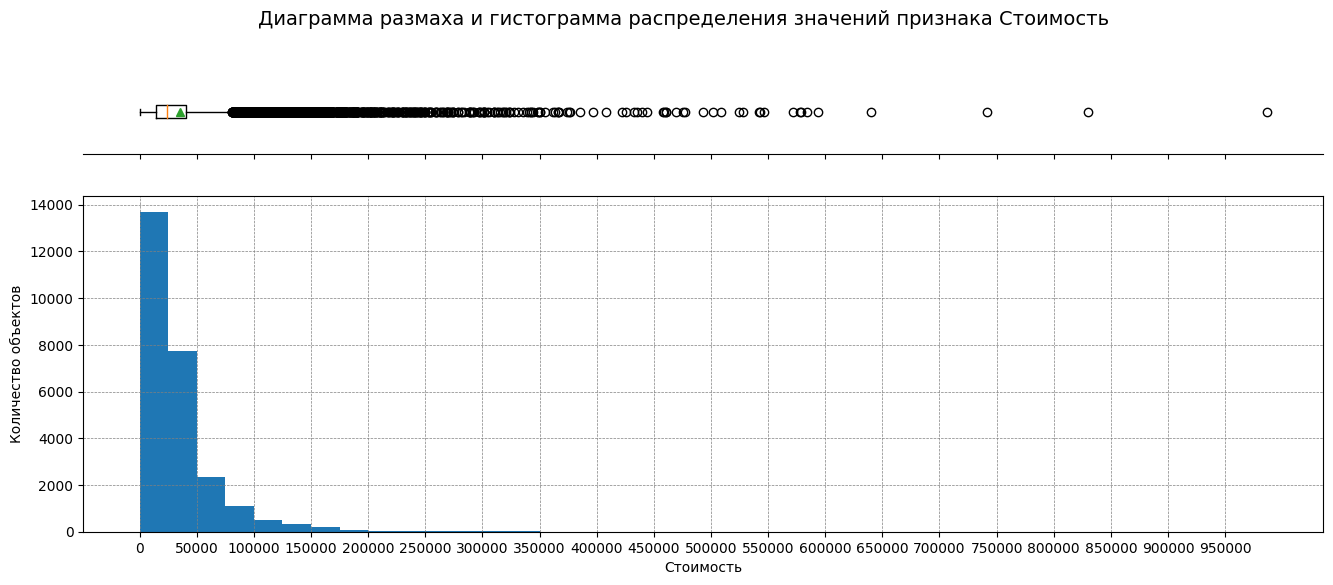

In [21]:
# Посмотрим, как рапределены значения признака Стоимость
# (обучающая выборка)
show_feature_distribution(df_train['Стоимость'])

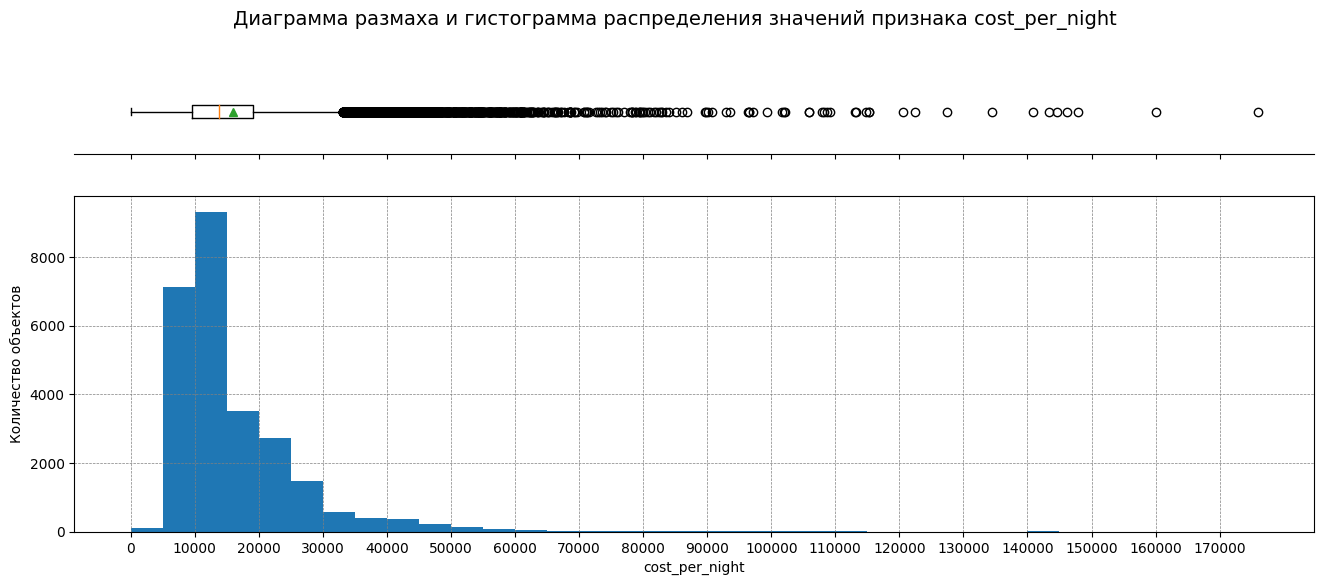

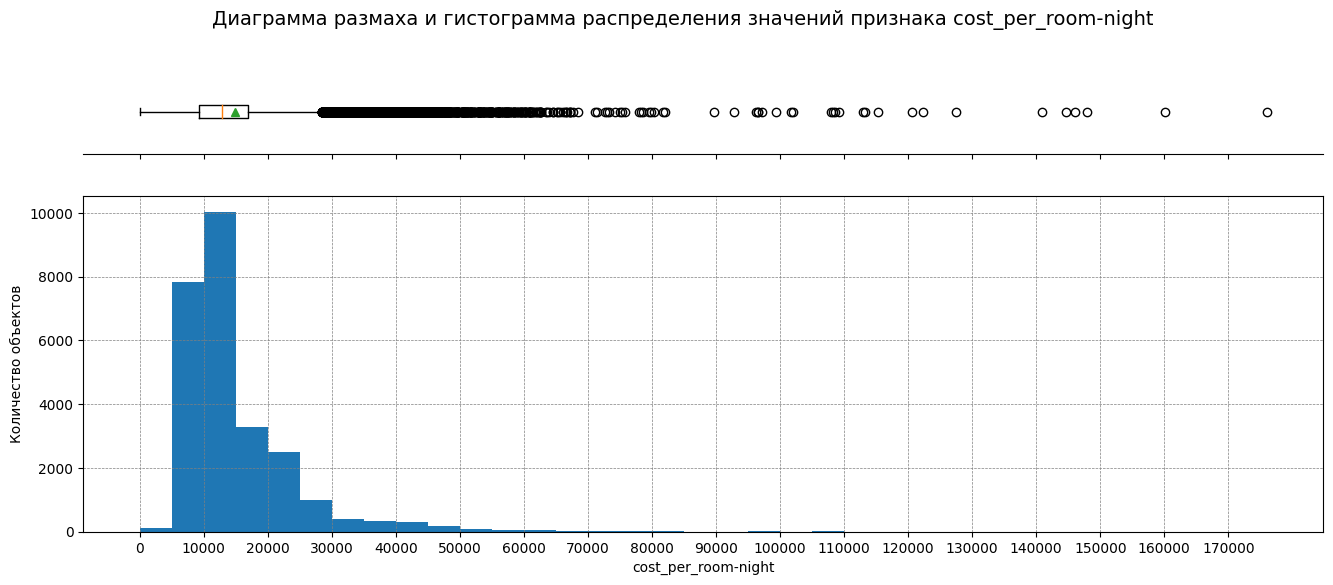

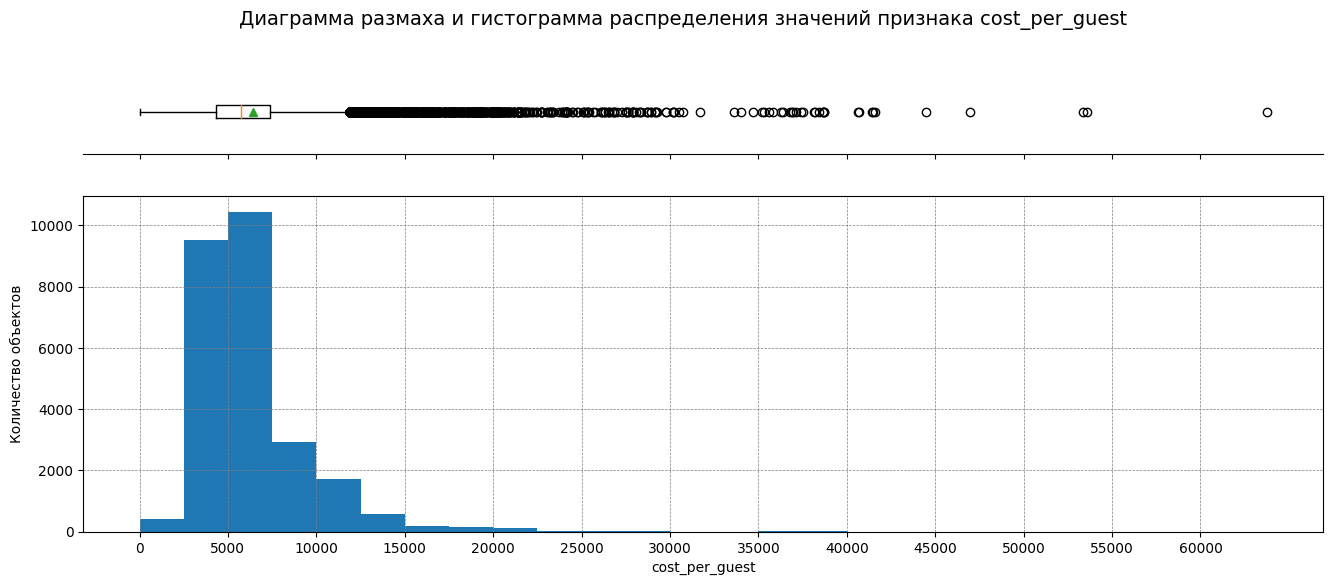

In [22]:
# Стоимость по всему бронированию зависит от количества
# номеров и количества ночей. Найдём стоимость одной ночи, а
# также средней стоимости номера за ночь, если в бронировании
# несколько номеров
df_train['cost_per_night'] = df_train['Стоимость']/df_train['Ночей']
show_feature_distribution(df_train['cost_per_night'])
df_train['cost_per_room-night'] = df_train['Стоимость']/(df_train['Ночей']*df_train['Номеров'])
show_feature_distribution(df_train['cost_per_room-night'])
df_train['cost_per_guest'] = df_train['Стоимость']/(df_train['Гостей'] * df_train['Ночей'])
show_feature_distribution(df_train['cost_per_guest'])

In [23]:
df_test['cost_per_guest'] = df_test['Стоимость']/(df_test['Гостей'] * df_test['Ночей'])

Из имеющихся данных можно сделать выводы:
- стоимость за ночь в большинстве бронирований не превышает 30 тыс руб, однако имеются выбросы и до 170 тыс руб.
- стоимость за одного гостя за одну ночь в большинстве бронирований не превышает 15 тыс руб, однако имеются выбросы до ~65 тыс руб.
Посмотрим связь с целевой переменной.

In [24]:
# Определим долю отменивших бронирование
average = df_train['is_cancelled'].mean()

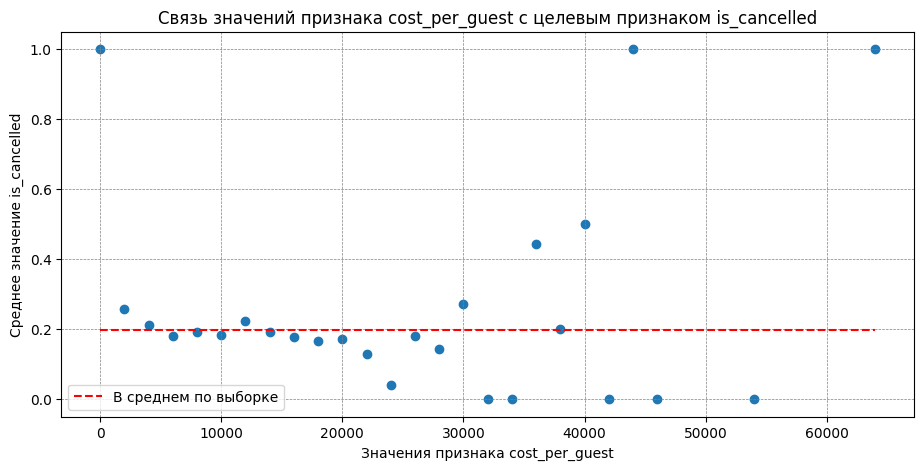

In [25]:
show_target_dependence(df_train,
                       factor='cost_per_guest',
                       target='is_cancelled',
                       is_cat = False)

#### Количество номеров

In [26]:
# Определим долю отменивших бронирование
average = df_train['is_cancelled'].mean()

In [27]:
# Посмотрим, как количество бронирований
# с разным количеством номеров в бронировании
df_train['Номеров'].value_counts()

Номеров
1    24188
2     1747
3      172
4       39
5       26
6        2
Name: count, dtype: int64

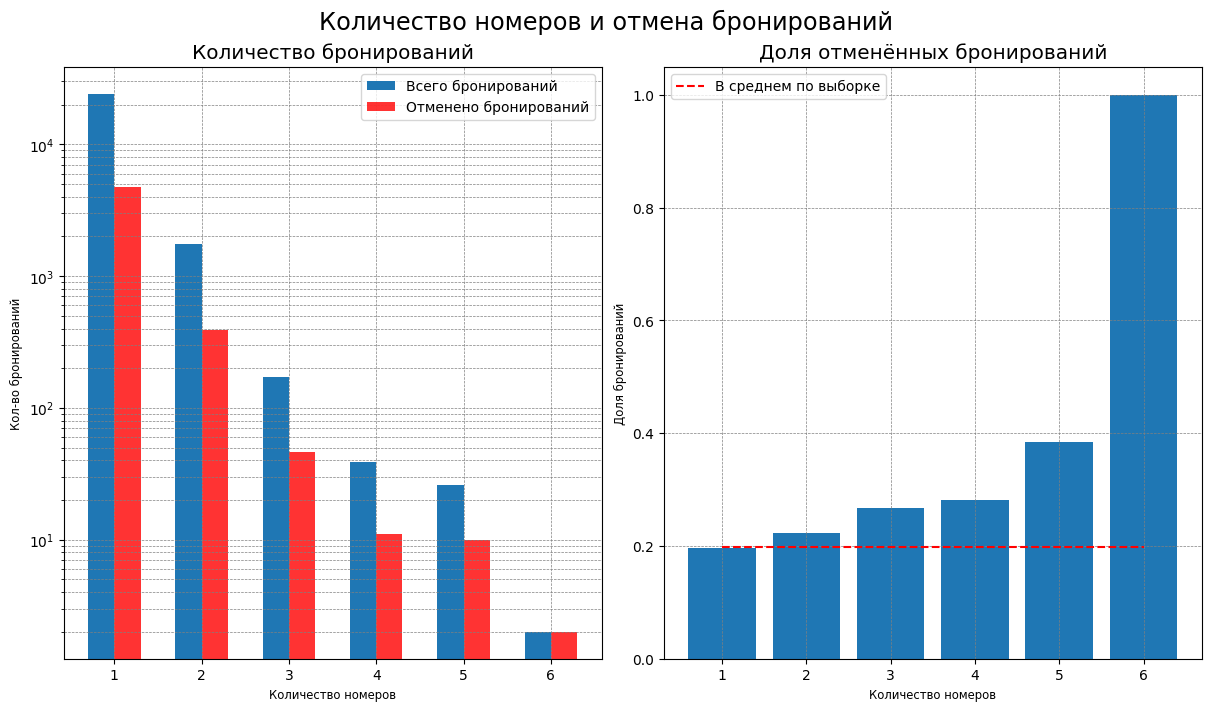

In [28]:
# Посмотрим соотношение отменивших и не отменивших бронирование в зависимости
# от количества номеров
# Настроим внешний вид области построения, обозначим оси
fig, ax = plt.subplots(
    ncols=2,
    nrows=1,
    figsize=(12, 7),
    sharex=False,
    gridspec_kw={'width_ratios': (0.5, 0.5)},
    constrained_layout=True,
)
fig.suptitle('Количество номеров и отмена бронирований', fontsize='xx-large')
ax[0].set_title('Количество бронирований', fontsize='x-large')
ax[1].set_title('Доля отменённых бронирований', fontsize='x-large')
ax[0].set_yscale('log')
data = df_train.groupby(by='Номеров')['is_cancelled'].agg(['count', 'sum', 'mean'])

# Построим графики
show_factor(data=data, ax=ax[:], factor_name='Количество номеров', rotation=0)

plt.show()

По имеющимся данным можно сделать выводы:
- чем больше номеров в бронировании, тем больше доля отменённых бронирований;
- количество бронирований с количеством номеров более 3 - редкость.

#### Ночей

In [29]:
# Посмотрим, как количество бронирований
# с разным количеством ночей
df_train['Ночей'].value_counts()

Ночей
1     10245
2      8712
3      3805
4      1778
5       758
6       445
7       230
8        70
10       47
9        33
13       13
11       10
14       10
12        8
16        2
20        2
31        1
15        1
26        1
18        1
17        1
21        1
Name: count, dtype: int64

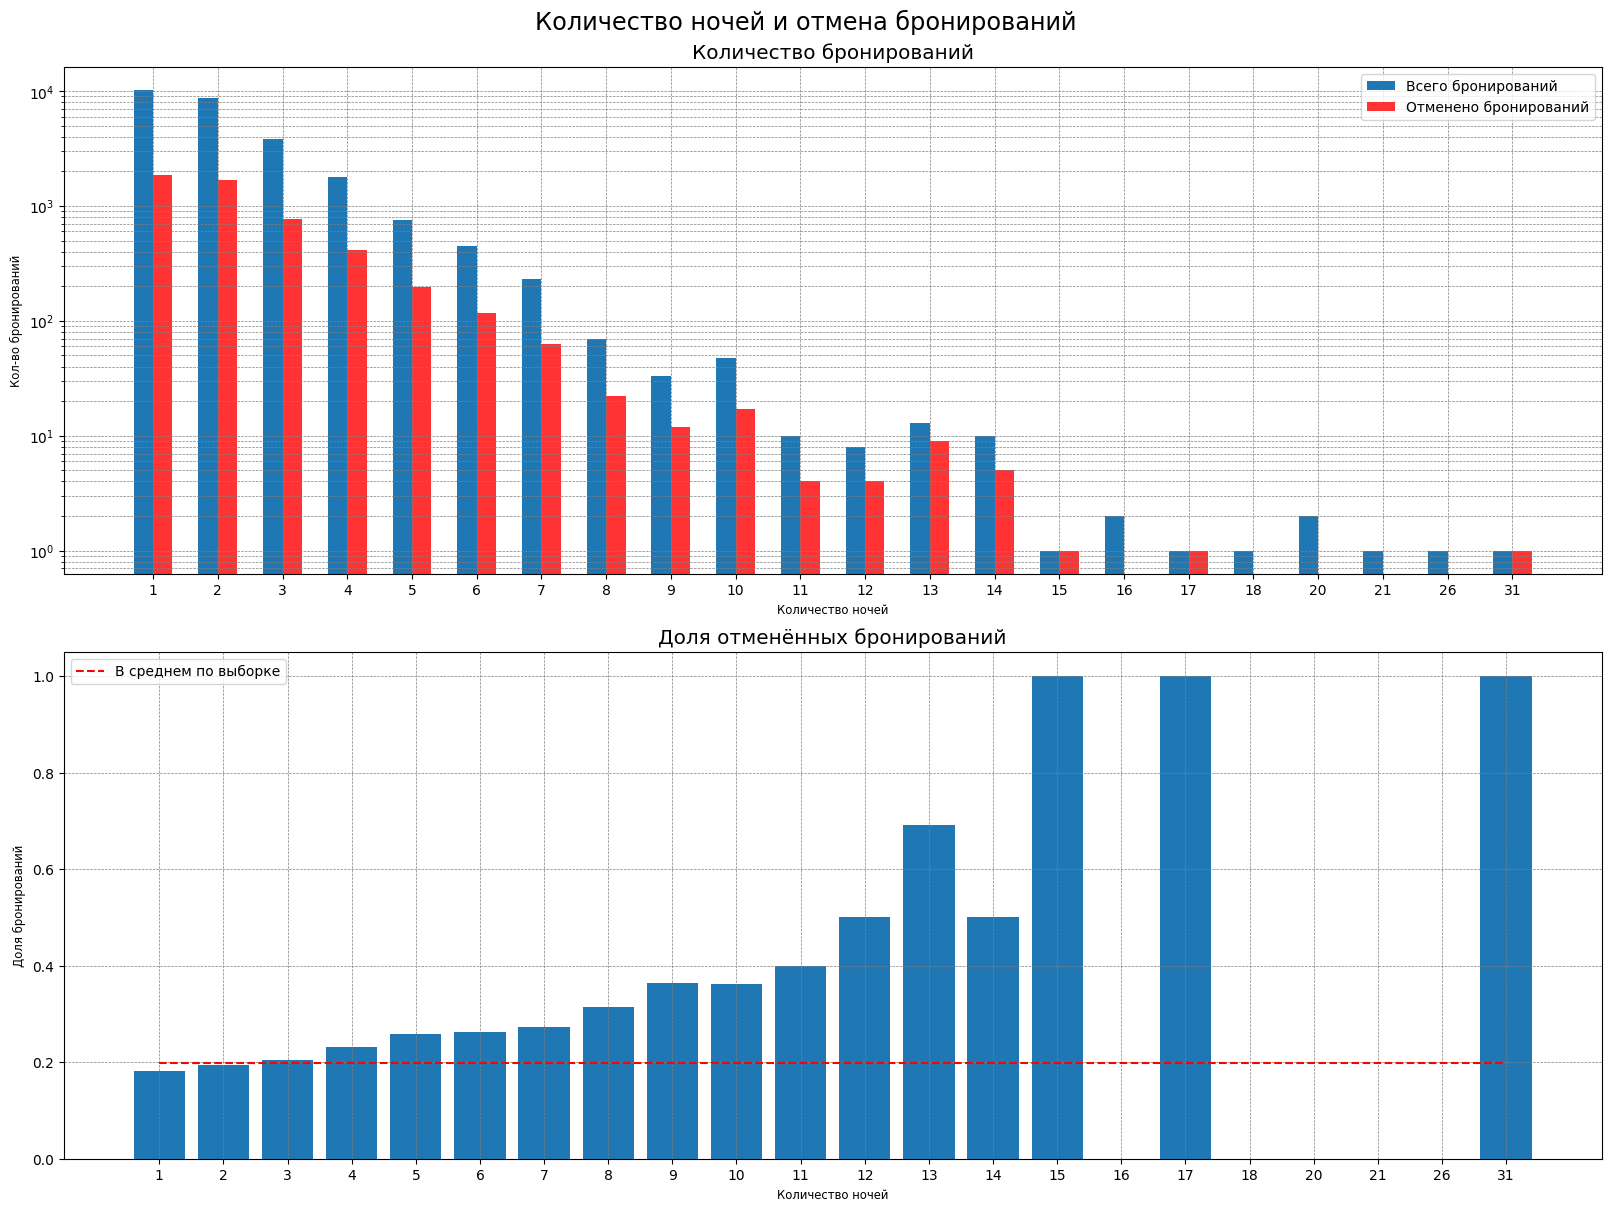

In [30]:
# Посмотрим соотношение отменивших и не отменивших бронирование в зависимости
# от количества ночей
# Настроим внешний вид области построения, обозначим оси
fig, ax = plt.subplots(
    ncols=1,
    nrows=2,
    figsize=(16, 12),
    sharex=False,
    gridspec_kw={'height_ratios': (0.5, 0.5)},
    constrained_layout=True,
)
fig.suptitle('Количество ночей и отмена бронирований', fontsize='xx-large')
ax[0].set_title('Количество бронирований', fontsize='x-large')
ax[1].set_title('Доля отменённых бронирований', fontsize='x-large')
ax[0].set_yscale('log')
data = df_train.groupby(by='Ночей')['is_cancelled'].agg(['count', 'sum', 'mean'])

# Построим графики
show_factor(data=data, ax=ax[:], factor_name='Количество ночей', rotation=0)

plt.show()

По имеющимся данным можно сделать выводы:
- для бронирований с количеством ночей до ~14 чем больше ночей, тем больше доля отмен;
- количество бронирований с количеством номеров более 14 - редкость, явной тенденции по таким бронированиям не просматривается.

#### Гостей

In [31]:
# Посмотрим, как количество бронирований
# с разным количеством ночей
df_train['Гостей'].value_counts()

Гостей
2     15115
3      4680
4      3154
1      1612
5       812
6       444
7       161
8       118
10       34
9        26
12        6
11        4
14        3
13        3
15        1
16        1
Name: count, dtype: int64

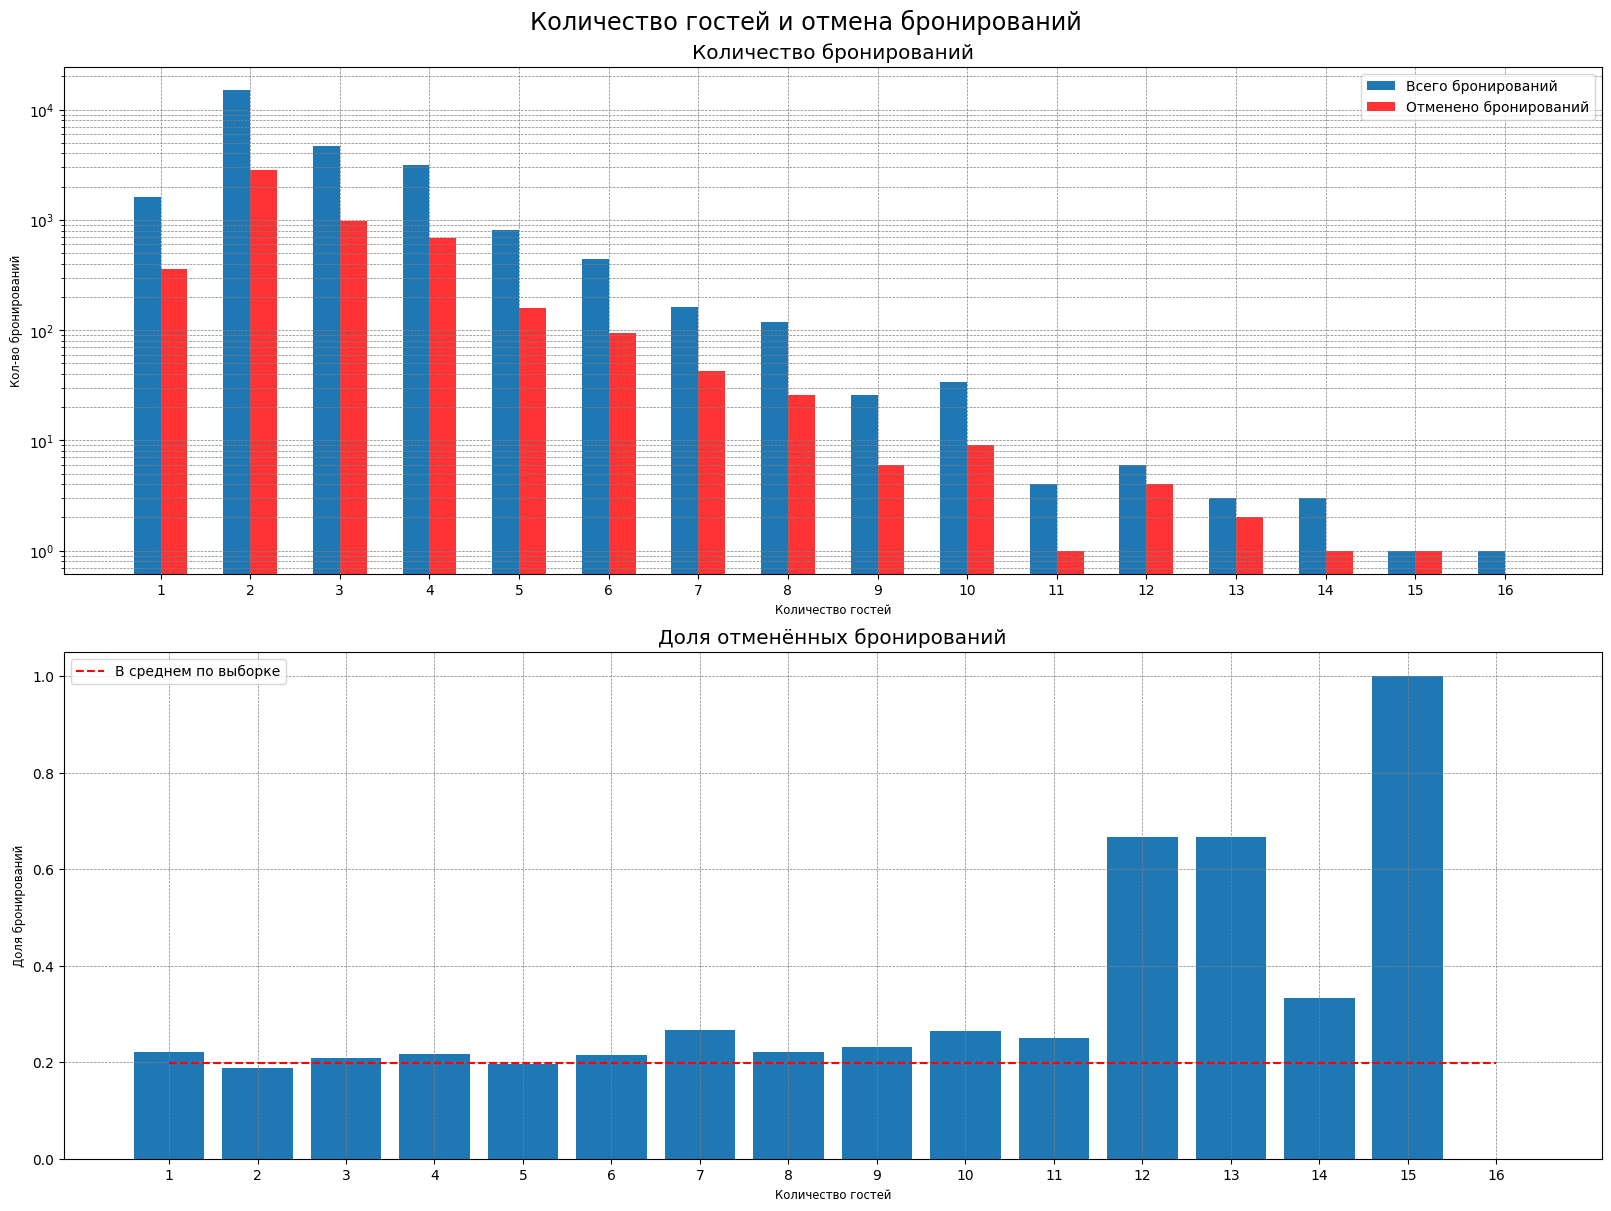

In [32]:
# Посмотрим соотношение отменивших и не отменивших бронирование в зависимости
# от количества ночей
# Настроим внешний вид области построения, обозначим оси
fig, ax = plt.subplots(
    ncols=1,
    nrows=2,
    figsize=(16, 12),
    sharex=False,
    gridspec_kw={'height_ratios': (0.5, 0.5)},
    constrained_layout=True,
)
fig.suptitle('Количество гостей и отмена бронирований', fontsize='xx-large')
ax[0].set_title('Количество бронирований', fontsize='x-large')
ax[1].set_title('Доля отменённых бронирований', fontsize='x-large')
ax[0].set_yscale('log')
data = df_train.groupby(by='Гостей')['is_cancelled'].agg(['count', 'sum', 'mean'])

# Построим графики
show_factor(data=data, ax=ax[:], factor_name='Количество гостей', rotation=0)

plt.show()

По имеющимся данным можно сделать выводы:
- бронирований с количеством гостей более 12 - редкость;
- доля отмен при количестве гостей до 12 приблизительно одинаковая.

#### Дата заезда

In [33]:
# Создадим столбцы с годом-месяцем, месяцем, с днём недели, с днём месяца
df_train['year_month'] = df_train['Заезд'].dt.to_period('M')
df_train['month'] = df_train['Заезд'].dt.month
df_train['dow'] = df_train['Заезд'].dt.day_of_week
df_train['day'] = df_train['Заезд'].dt.day

In [34]:
# Аналогично в тестовой выборке
df_test['year_month'] = df_test['Заезд'].dt.to_period('M')
df_test['month'] = df_test['Заезд'].dt.month
df_test['dow'] = df_test['Заезд'].dt.day_of_week
df_test['day'] = df_test['Заезд'].dt.day

In [35]:
# Для анализа изменения количества бронирований по месяцам
# Сгруппируем данные
month_data = df_train.pivot_table(values='Заезд',index='month', columns='Гостиница',
                            aggfunc='count').fillna(0).astype(int)
month_data

Гостиница,1,2,3,4
month,,,,
1,829,380,458,134
2,989,485,593,149
3,816,431,391,129
4,499,589,462,185
5,568,709,753,195
6,622,740,841,239
7,802,903,1007,286
8,969,842,990,270
9,549,787,939,228


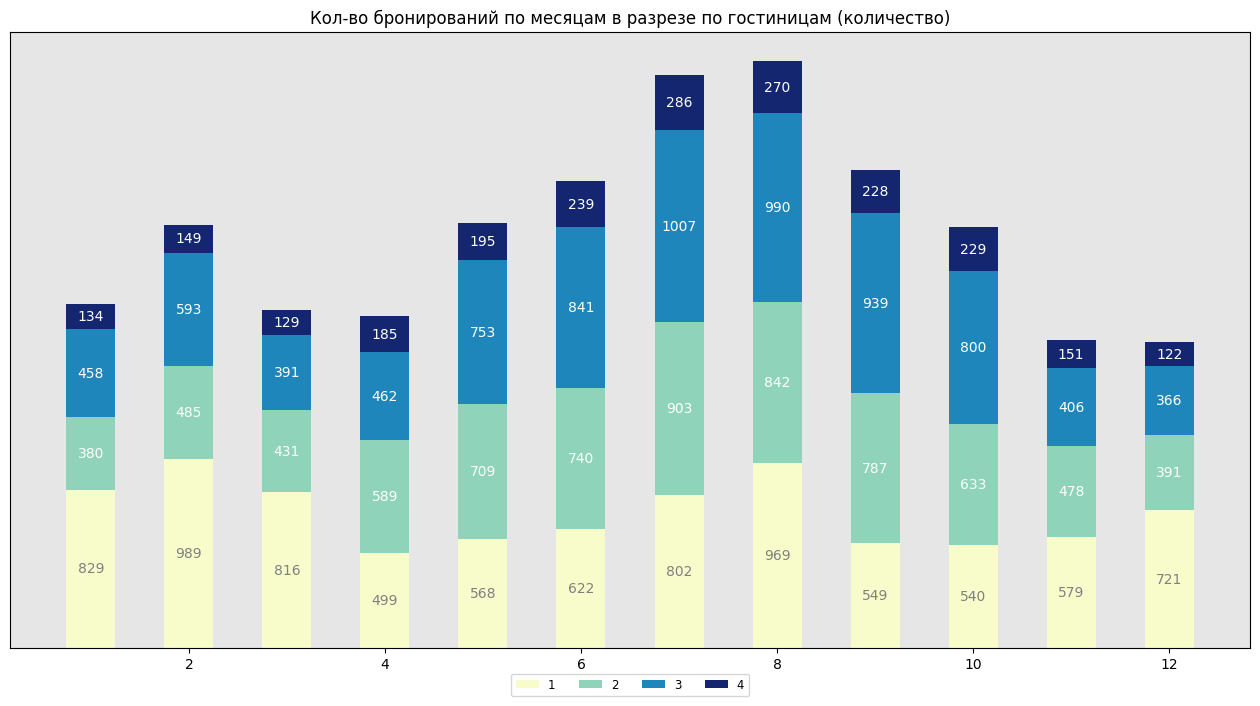

In [36]:
# Посмотрим, как изменяется по месяцам количество бронирований
# разных гостиниц
survey_v(results=dict(
    zip(month_data.index,
        month_data.values)
),
       category_names=month_data.columns,
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (количество)')
plt.show()

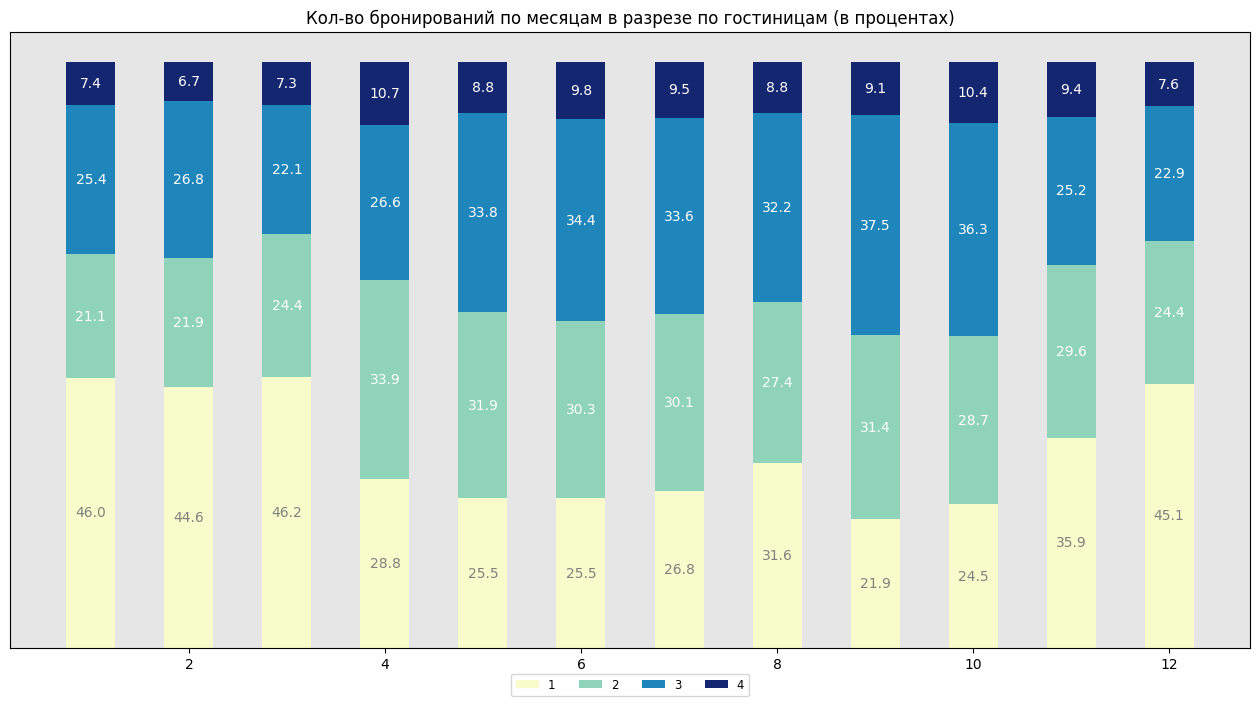

In [37]:
# Посмотрим как изменяется доля бронирований в разных гостиницах
survey_v(results=dict(
    zip(month_data.index,
        month_data.values)
),
       category_names=month_data.columns,
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

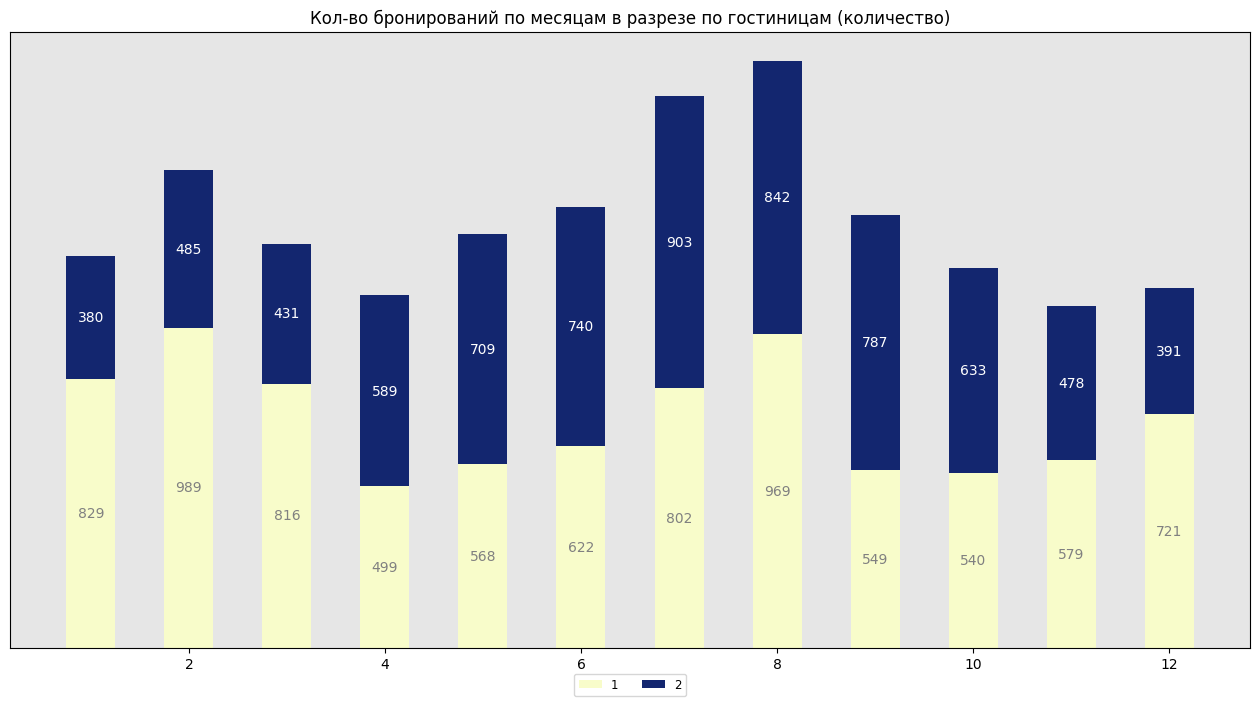

In [38]:
# Посмотрим, как изменяется по месяцам количество бронирований
# гостиниц 1-2
survey_v(results=dict(
    zip(month_data.index,
        month_data.values[:, :2])
),
       category_names=month_data.columns,
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (количество)')
plt.show()

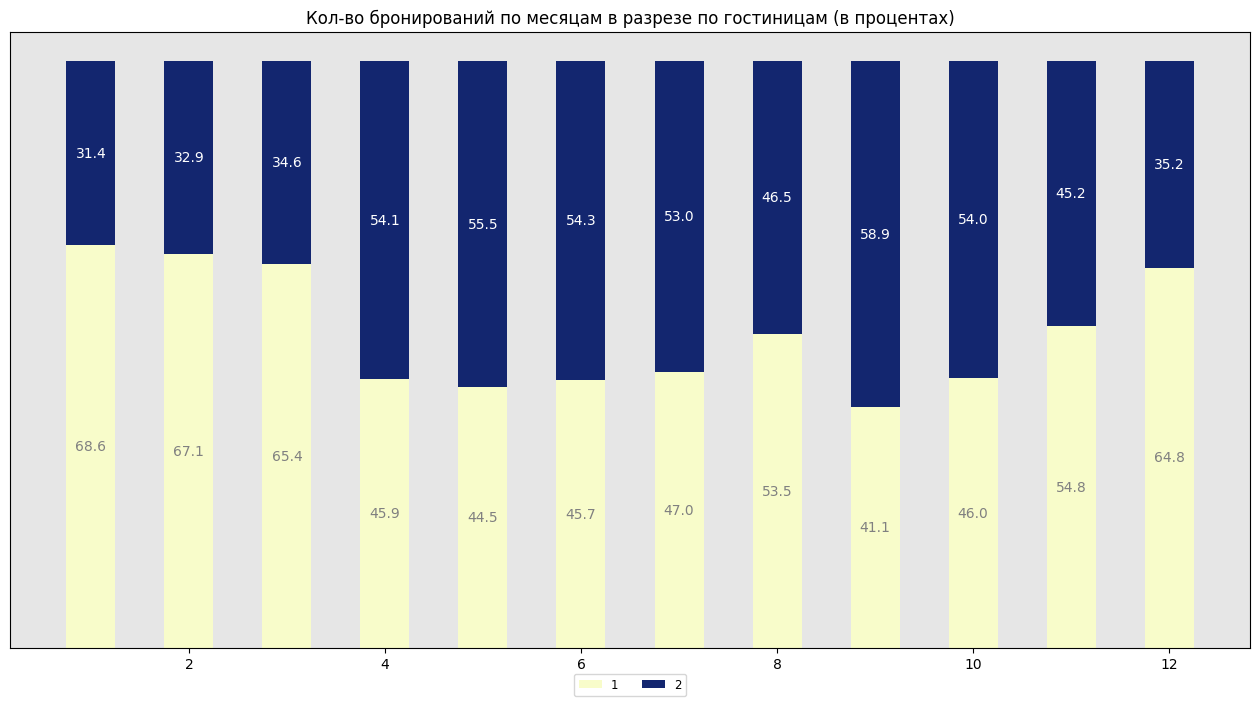

In [39]:
# Посмотрим как изменяется доля бронирований в гостиница 1-2
survey_v(results=dict(
    zip(month_data.index,
        month_data.values[:, :2])
),
       category_names=month_data.columns,
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

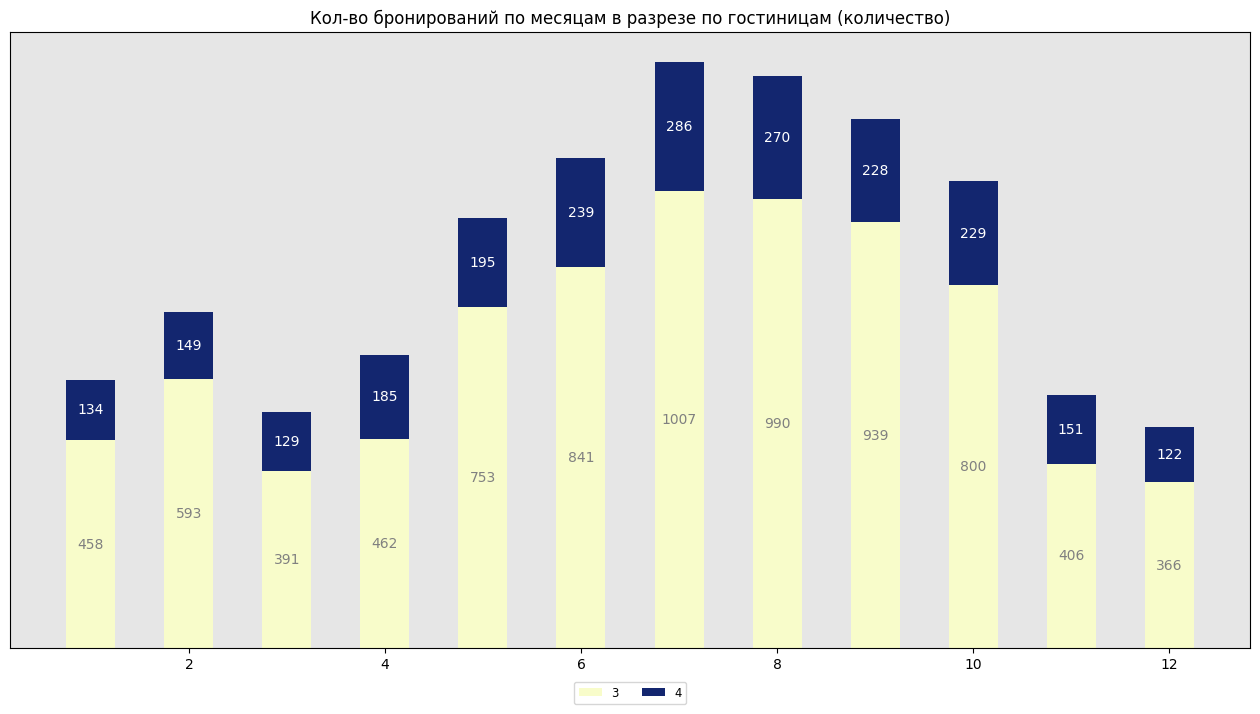

In [40]:
# Посмотрим, как изменяется по месяцам количество бронирований
# гостиниц 3-4
survey_v(results=dict(
    zip(month_data.index,
        month_data.values[:, 2:])
),
       category_names=month_data.columns[2:],
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (количество)')
plt.show()

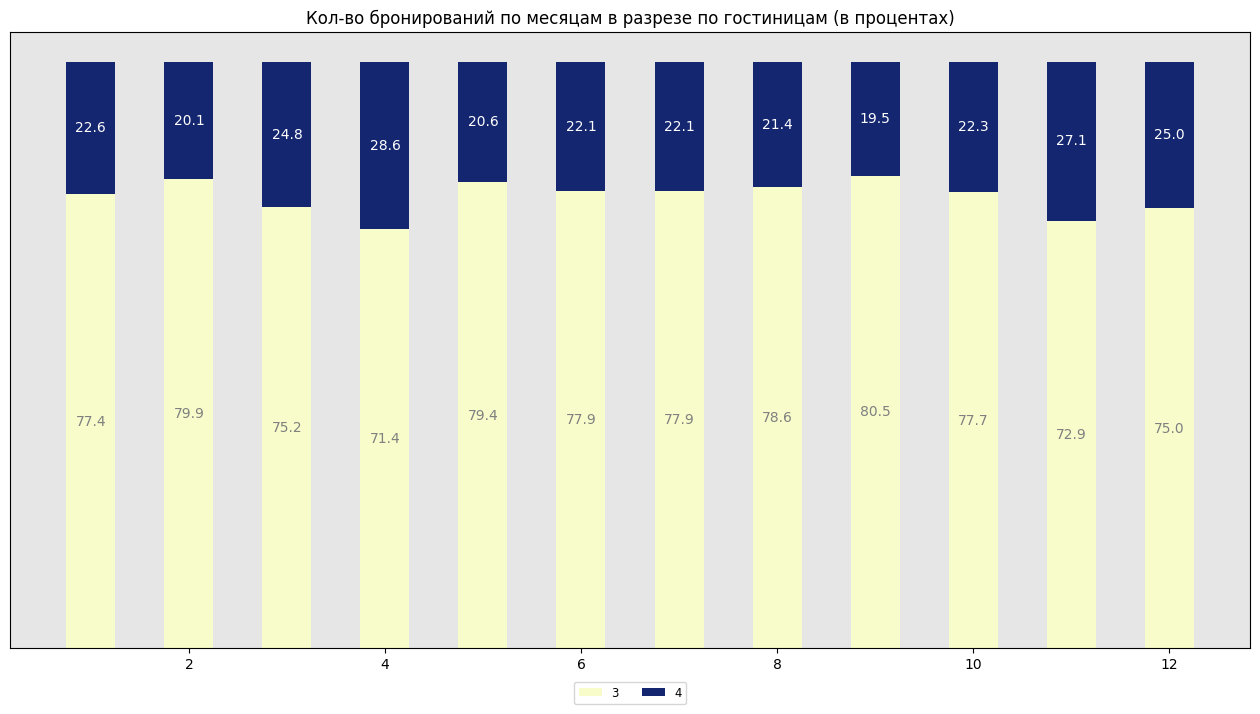

In [41]:
# Посмотрим как изменяется доля бронирований в гостиницах 3-4
survey_v(results=dict(
    zip(month_data.index,
        month_data.values[:, 2:])
),
       category_names=month_data.columns[2:],
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

По имеющимся данным можно сделать выводы:
- по количеству бронирований имеется сезонность. Летом и в декабре-январе бронирований больше;
- создадим столбец `load` с категорией по частоте бронирований. 7,8 месяцы - 'high',  5, 6, 9, 10 - 'medium', остальные месяцы - 'low'

In [42]:
df_train.loc[df_train['month'].isin([7, 8]), 'load'] = 'high'
df_train.loc[df_train['month'].isin([5, 6, 9, 10]), 'load'] = 'medium'
df_train['load'] =df_train['load'].fillna('low')
df_train['load'].value_counts(dropna=False)

load
low       10733
medium     9372
high       6069
Name: count, dtype: int64

In [43]:
df_test.loc[df_test['month'].isin([7, 8]), 'load'] = 'high'
df_test.loc[df_test['month'].isin([5, 6, 9, 10]), 'load'] = 'medium'
df_test['load'] =df_test['load'].fillna('low')
df_test['load'].value_counts(dropna=False)

load
low       4645
medium    4042
high      2531
Name: count, dtype: int64

In [44]:
# Для анализа изменения количества отклонений во времени
# Сгруппируем данные
year_month_data = df_train.pivot_table(values='Заезд',index='year_month', columns='Гостиница',
                            aggfunc='count').fillna(0).astype(int)
year_month_data

Гостиница,1,2,3,4
year_month,,,,
2022-01,206,95,116,37
2022-02,447,239,314,63
2022-03,398,266,245,71
2022-04,297,372,321,115
2022-05,324,407,407,100
2022-06,321,405,493,126
2022-07,423,464,524,139
2022-08,454,356,444,129
2022-09,185,350,461,98


Видим, что с февраля-марта 2024 года количество бронирований резко сократилось, либо в данных отсутсвует информация о всех бронированиях за указанный период. Уберём данные о бронированиях с марта по август 2024 года

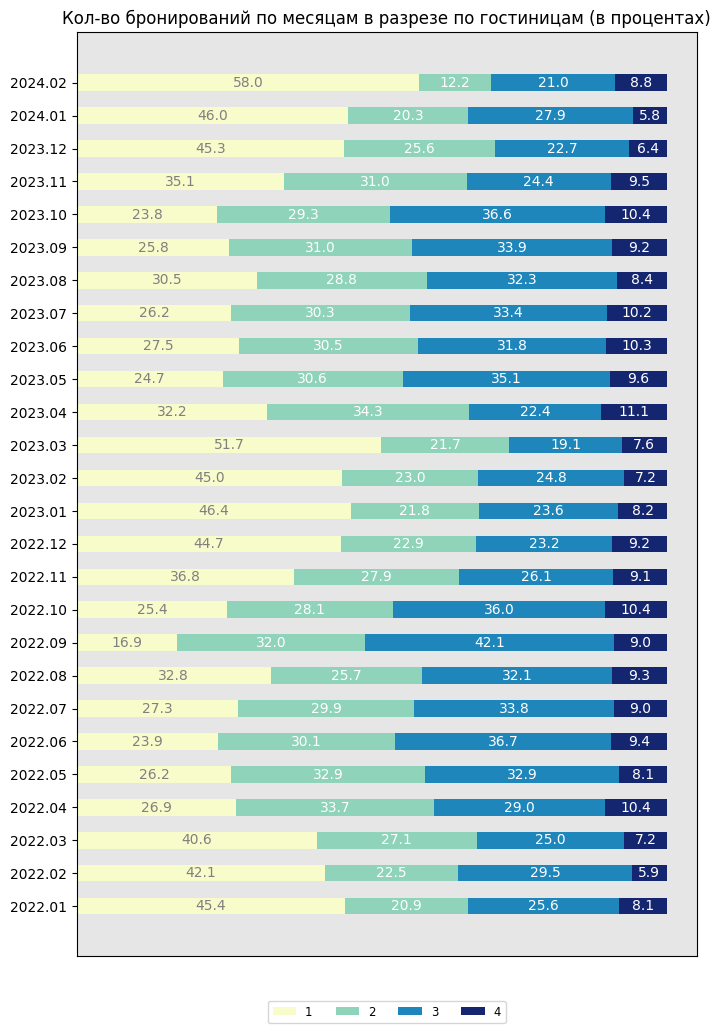

In [45]:
# Посмотрим как изменяется доля бронирований в разных гостиницах
survey_h(results=dict(
    zip(year_month_data.index.strftime(date_format='%Y.%m')[:-4],
        year_month_data.values[:-4,:])
),
       category_names=year_month_data.columns,
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

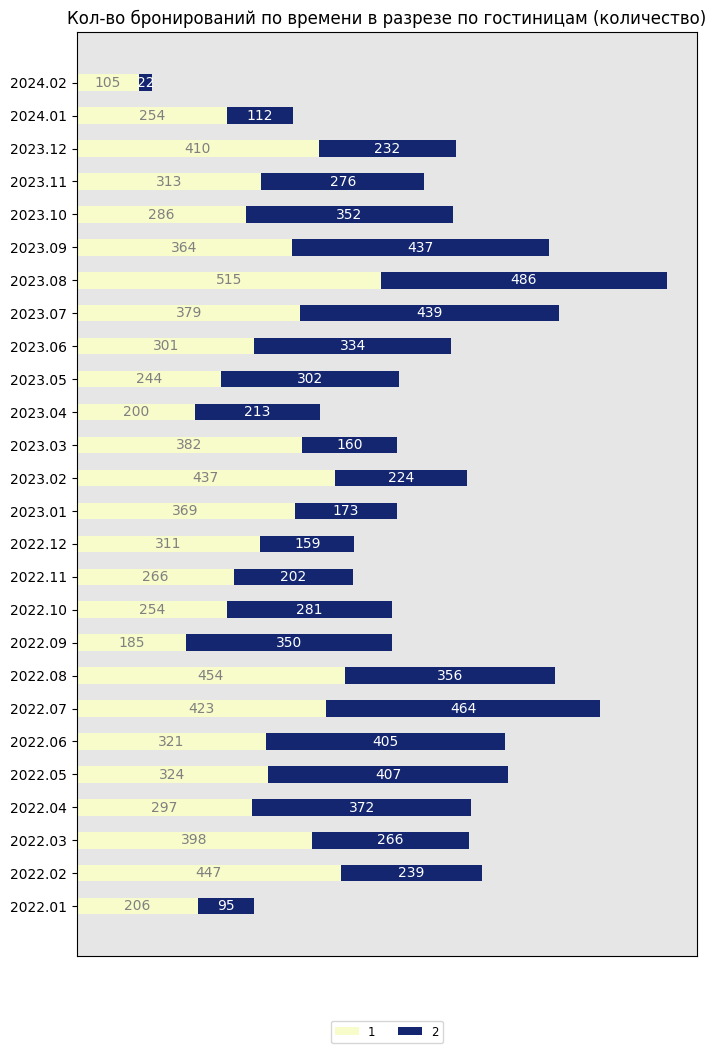

In [46]:
# Посмотрим, как изменяется по времени количество бронирований
# гостиниц 1-2
survey_h(results=dict(
    zip(year_month_data.index.strftime(date_format='%Y.%m'),
        year_month_data.values[:-4, :2])
),
       category_names=month_data.columns[:2],
       title='Кол-во бронирований по времени в разрезе по гостиницам (количество)')
plt.show()

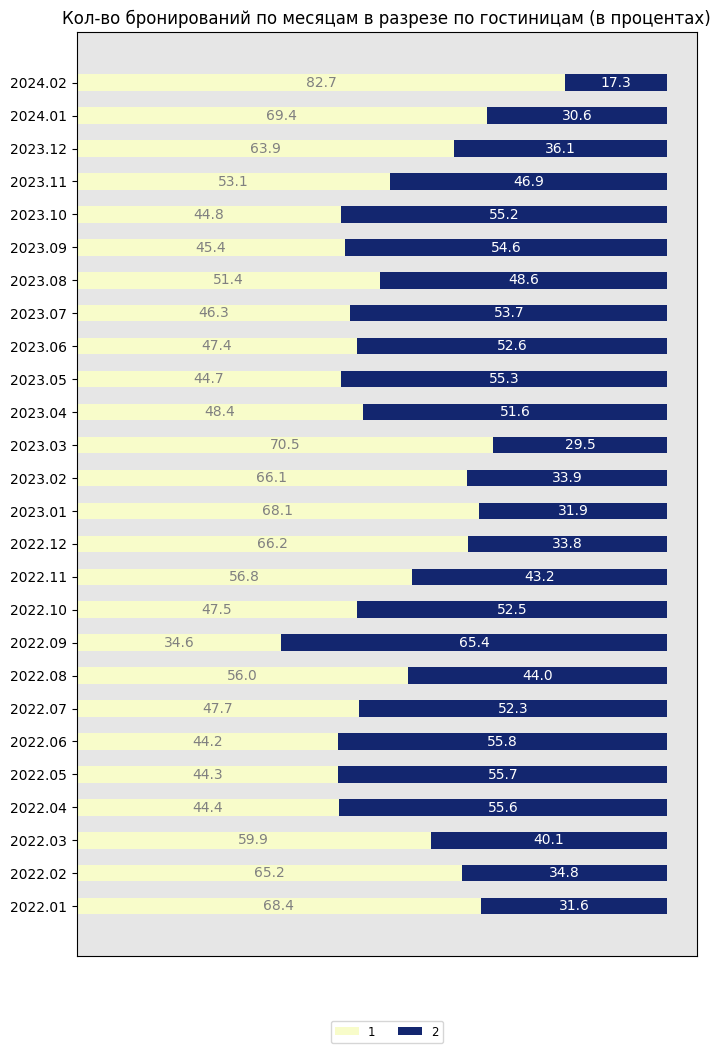

In [47]:
# Посмотрим как изменяется доля бронирований в гостиницах 1-2
survey_h(results=dict(
    zip(year_month_data.index.strftime(date_format='%Y.%m'),
        year_month_data.values[:-4, :2])
),
       category_names=year_month_data.columns[:2],
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

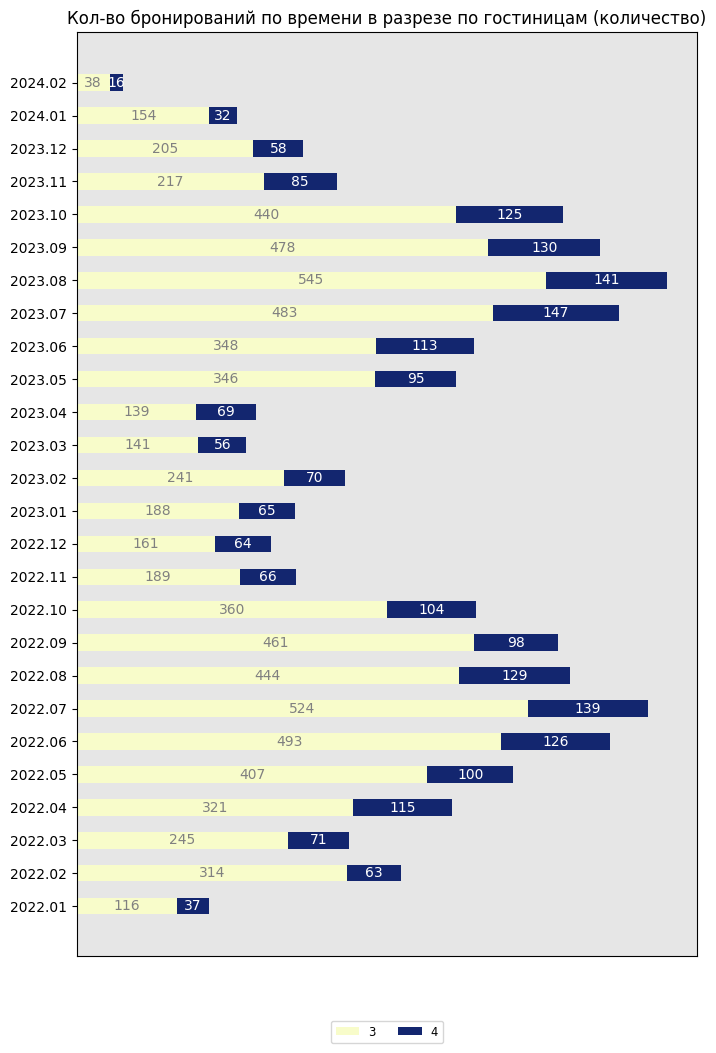

In [48]:
# Посмотрим, как изменяется по времени количество бронирований
# гостиниц 3-4
survey_h(results=dict(
    zip(year_month_data.index.strftime(date_format='%Y.%m'),
        year_month_data.values[:-4, 2:])
),
       category_names=month_data.columns[2:],
       title='Кол-во бронирований по времени в разрезе по гостиницам (количество)')
plt.show()

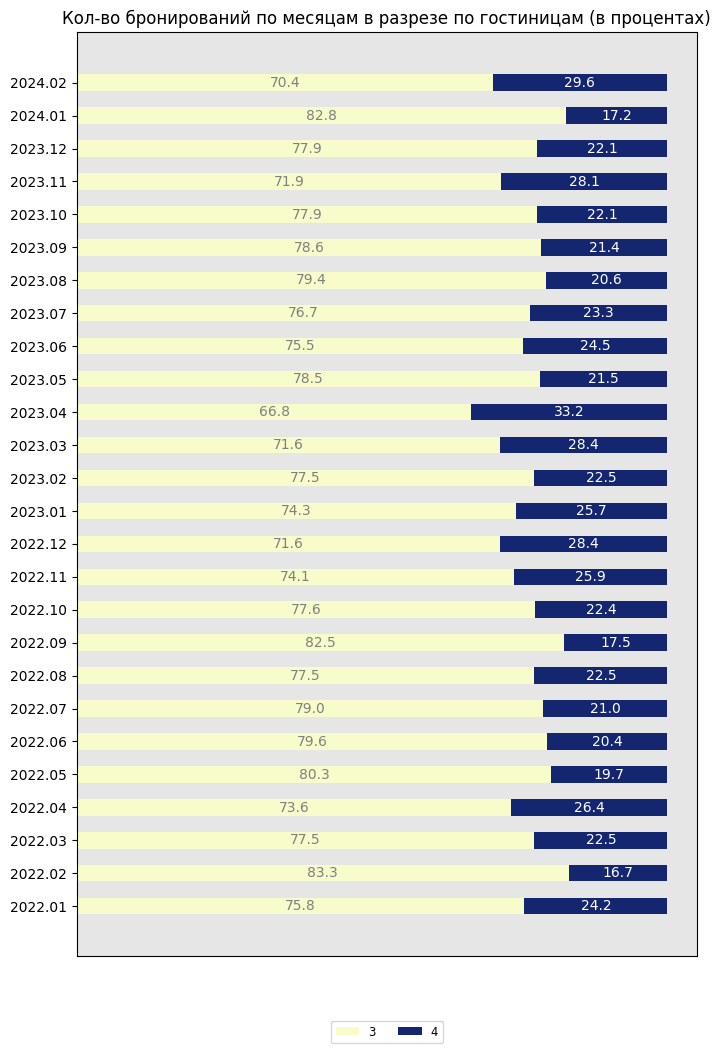

In [49]:
# Посмотрим как изменяется доля бронирований в гостиницах 3-4
survey_h(results=dict(
    zip(year_month_data.index.strftime(date_format='%Y.%m'),
        year_month_data.values[:-4, 2:])
),
       category_names=year_month_data.columns[2:],
       title='Кол-во бронирований по месяцам в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

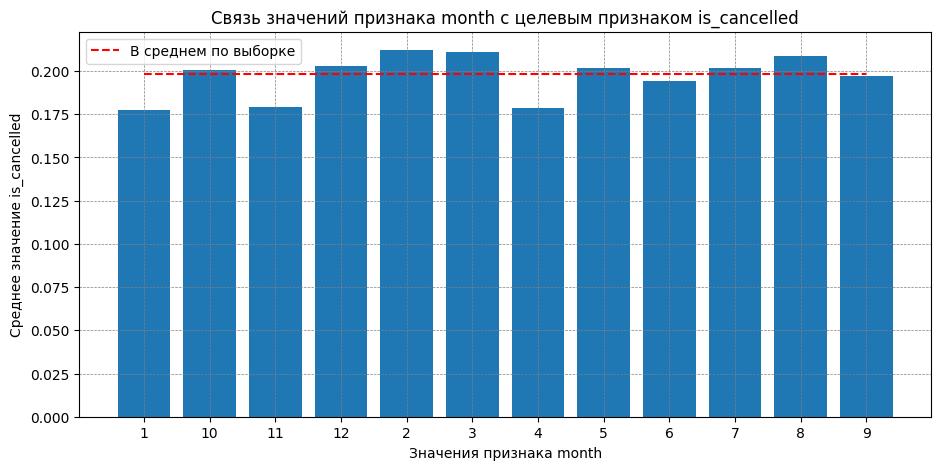

In [50]:
# Посмотрим связь отмены бронирования и месяца
show_target_dependence(df_train,
                       factor='month',
                       target='is_cancelled',
                       is_cat = True)

Видим, что чаще отменяются бронирования с заездом в феврале-марте и августе. Реже - январь, ноябрь, апрель.

In [51]:
# Для анализа изменения количества бронирований по месяцам
# Сгруппируем данные
dow_data = df_train.pivot_table(values='Заезд',index='dow', columns='Гостиница',
                            aggfunc='count').fillna(0).astype(int)
dow_data

Гостиница,1,2,3,4
dow,,,,
0,1066,985,1236,324
1,791,824,965,275
2,782,715,895,269
3,749,792,947,271
4,1452,1332,1336,455
5,2023,1562,1365,387
6,1620,1158,1262,336


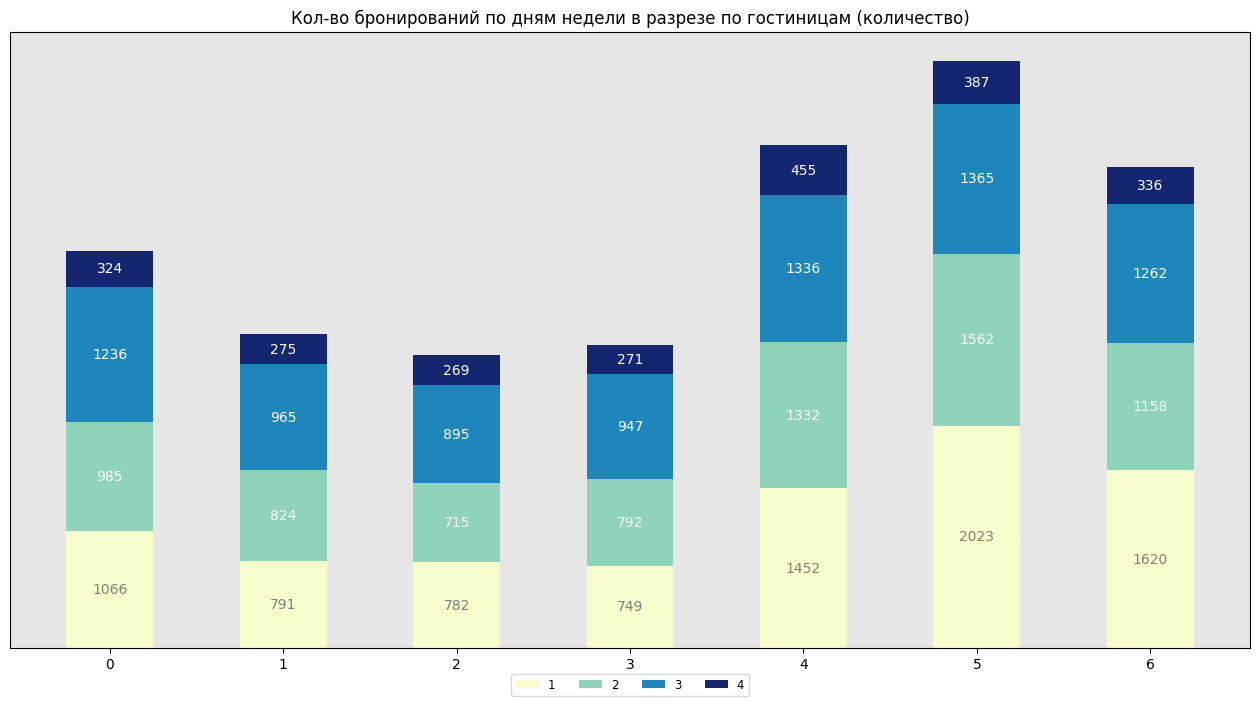

In [52]:
# Посмотрим, как изменяется по дням недели количество бронирований
# разных гостиниц
survey_v(results=dict(
    zip(dow_data.index,
        dow_data.values)
),
       category_names=dow_data.columns,
       title='Кол-во бронирований по дням недели в разрезе по гостиницам (количество)')
plt.show()

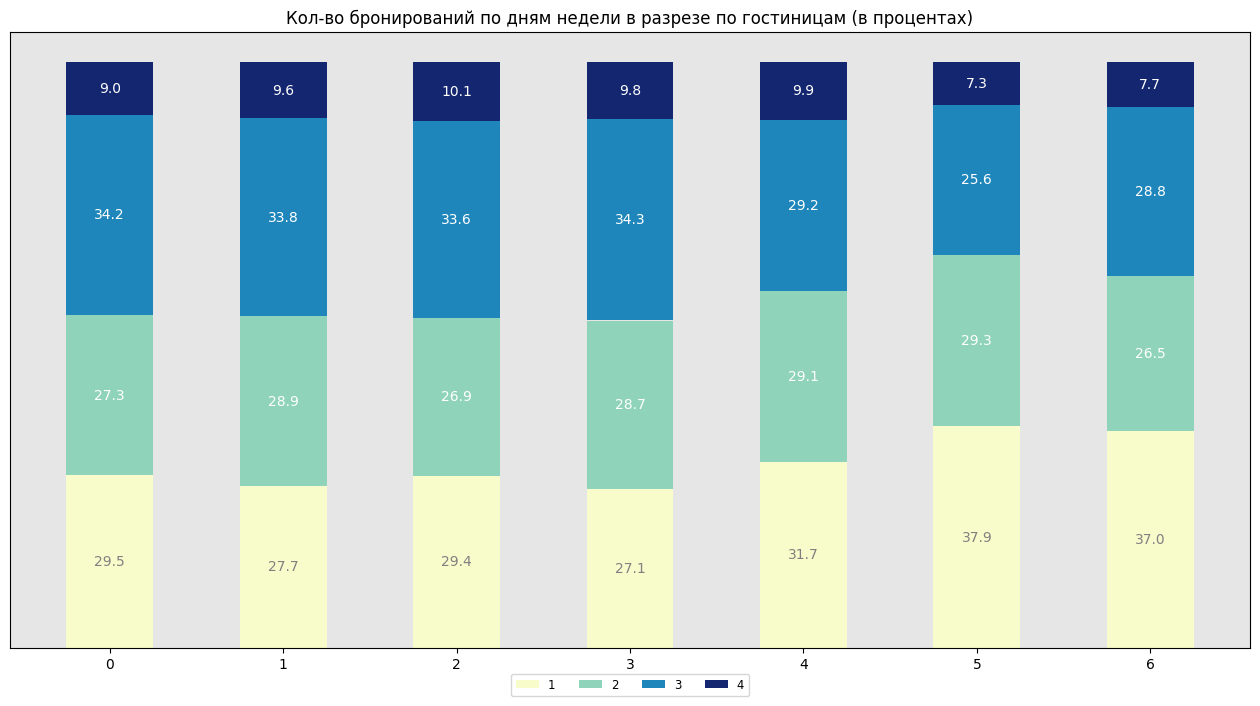

In [53]:
# Посмотрим как изменяется доля бронирований в разных гостиницах
survey_v(results=dict(
    zip(dow_data.index,
        dow_data.values)
),
       category_names=dow_data.columns,
       title='Кол-во бронирований по дням недели в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

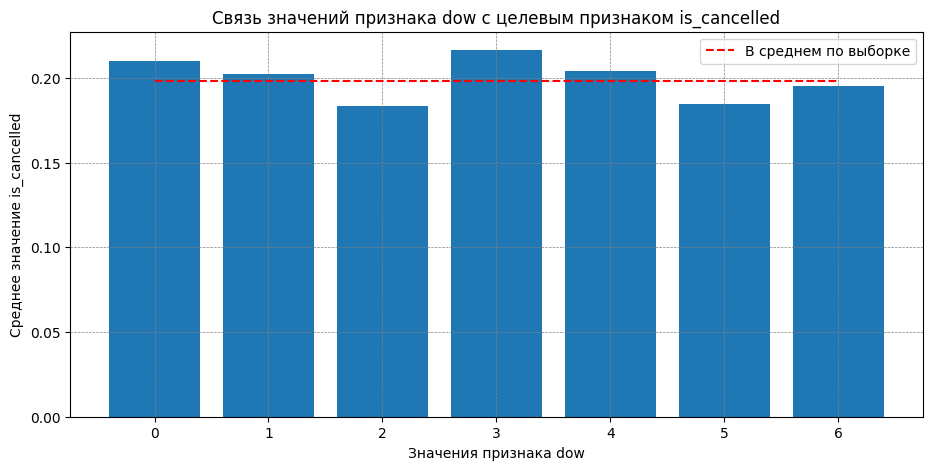

In [54]:
# Посмотрим связь отмены бронирования и дня недели заезда
show_target_dependence(df_train,
                       factor='dow',
                       target='is_cancelled',
                       is_cat = True)

Видим, что чаще отменяются бронирования с заездом в четверг, реже - в среду и субботу.

In [55]:
# Для анализа изменения количества бронирований по месяцам
# Сгруппируем данные
day_data = df_train.pivot_table(values='Заезд',index='day', columns='Гостиница',
                            aggfunc='count').fillna(0).astype(int)
day_data

Гостиница,1,2,3,4
day,,,,
1,267,286,229,83
2,271,275,254,78
3,258,291,334,87
4,282,240,284,72
5,275,212,269,89
6,271,262,268,85
7,220,230,262,80
8,318,231,252,83
9,284,264,276,92


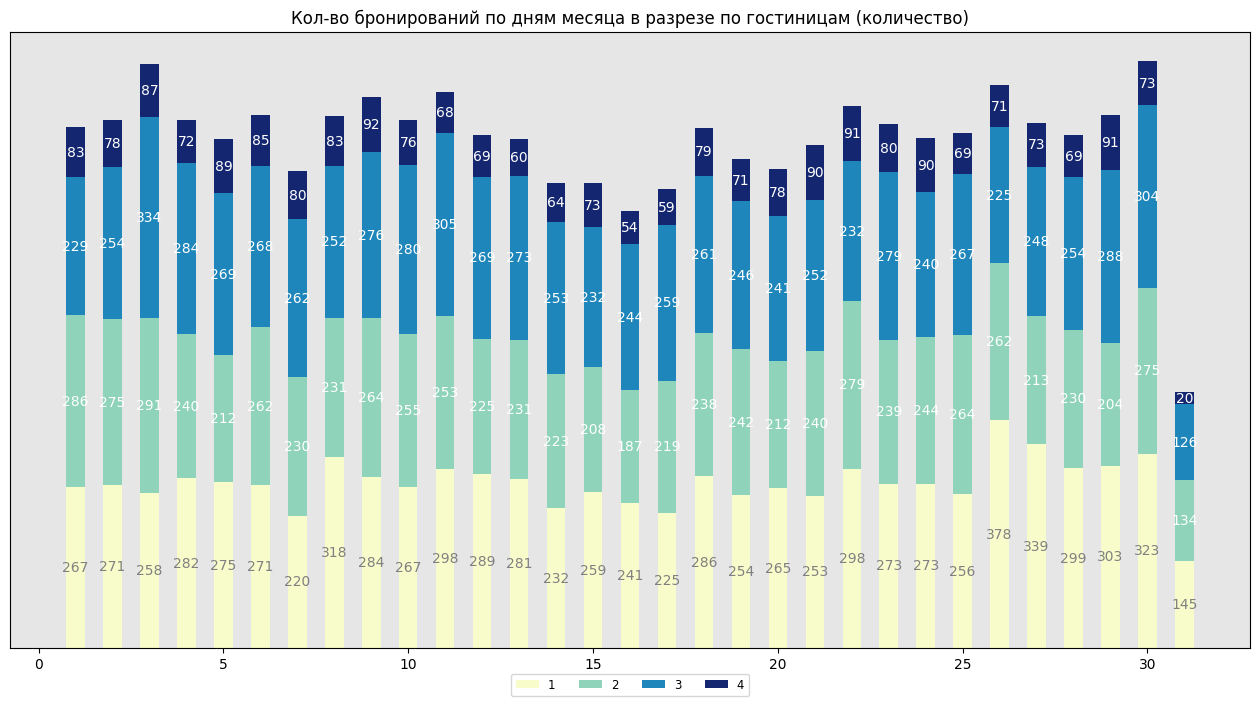

In [56]:
# Посмотрим, как изменяется по дням месяца количество бронирований
# разных гостиниц
survey_v(results=dict(
    zip(day_data.index,
        day_data.values)
),
       category_names=day_data.columns,
       title='Кол-во бронирований по дням месяца в разрезе по гостиницам (количество)')
plt.show()

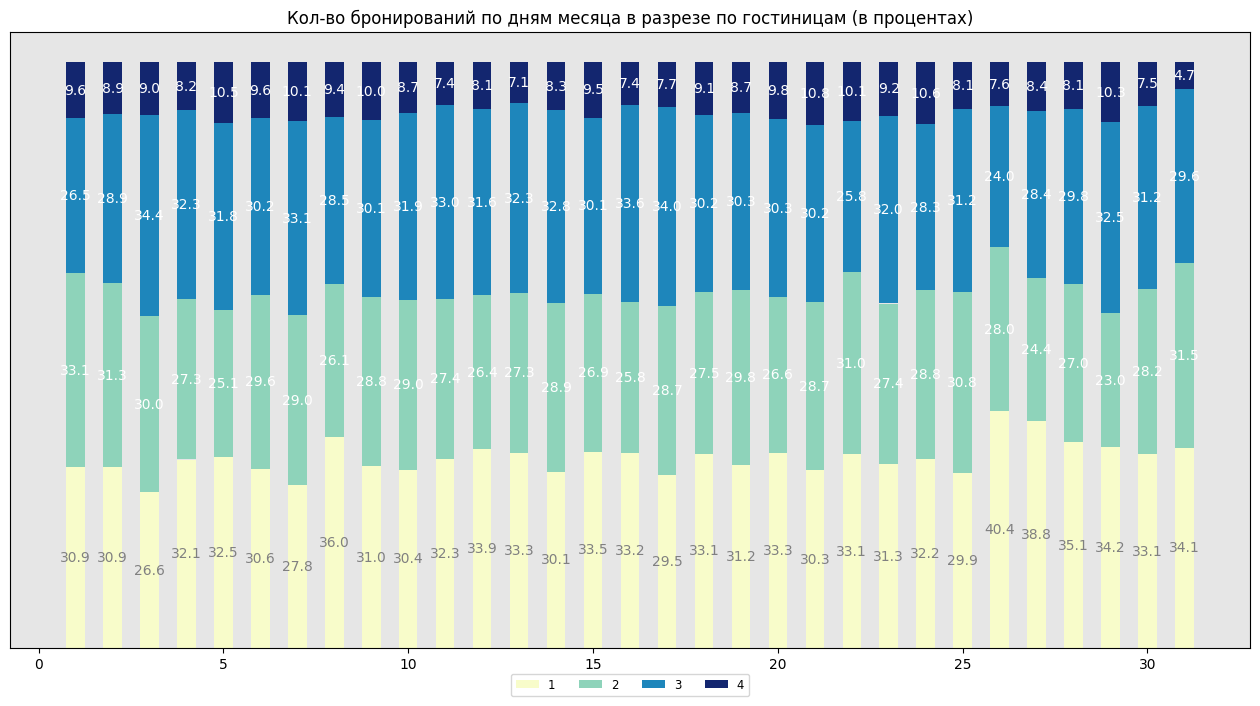

In [57]:
# Посмотрим как изменяется доля бронирований в разных гостиницах
survey_v(results=dict(
    zip(day_data.index,
        day_data.values)
),
       category_names=day_data.columns,
       title='Кол-во бронирований по дням месяца в разрезе по гостиницам (в процентах)',
       percents=True)
plt.show()

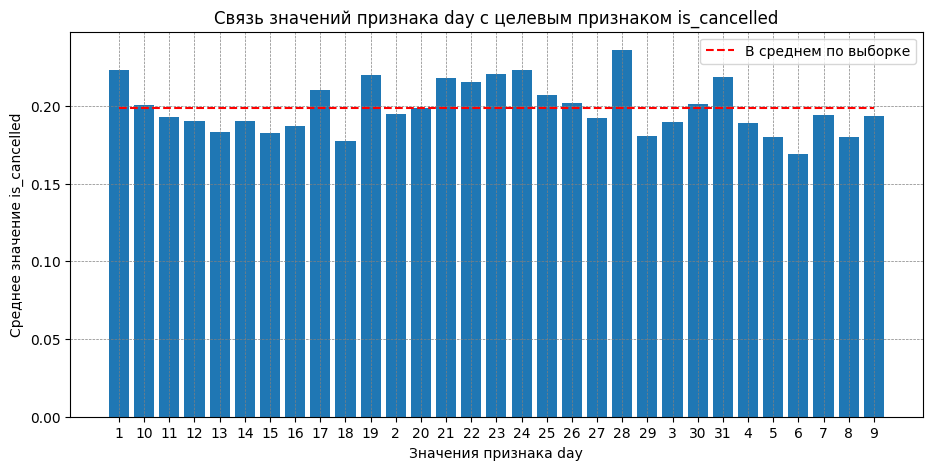

In [58]:
# Посмотрим связь отмены бронирования и дня месяца
show_target_dependence(df_train,
                       factor='day',
                       target='is_cancelled',
                       is_cat = True)

Видим, что явной тенденции не наблюдается.

Создадим новый признак: дней от бронирования до заезда.

In [59]:
df_train['days_before'] = (df_train['Заезд'] - df_train['Дата бронирования']).dt.days
df_test['days_before'] = (df_test['Заезд'] - df_test['Дата бронирования']).dt.days

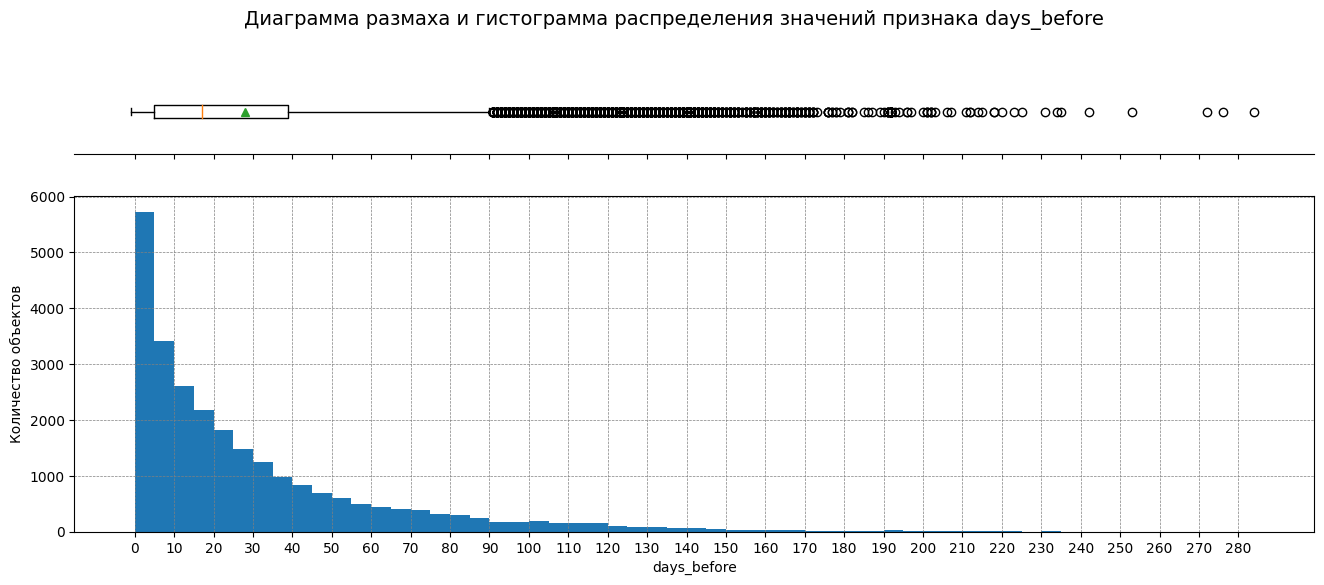

In [60]:
show_feature_distribution(df_train['days_before'])

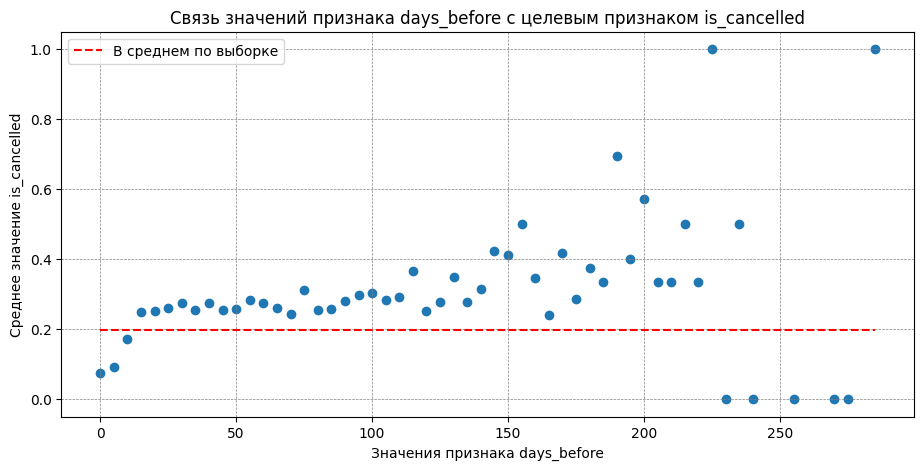

In [61]:
# Посмотрим связь отмены бронирования и количества дней от бронирования до заезда
show_target_dependence(df_train,
                       factor='days_before',
                       target='is_cancelled',
                       is_cat = False)

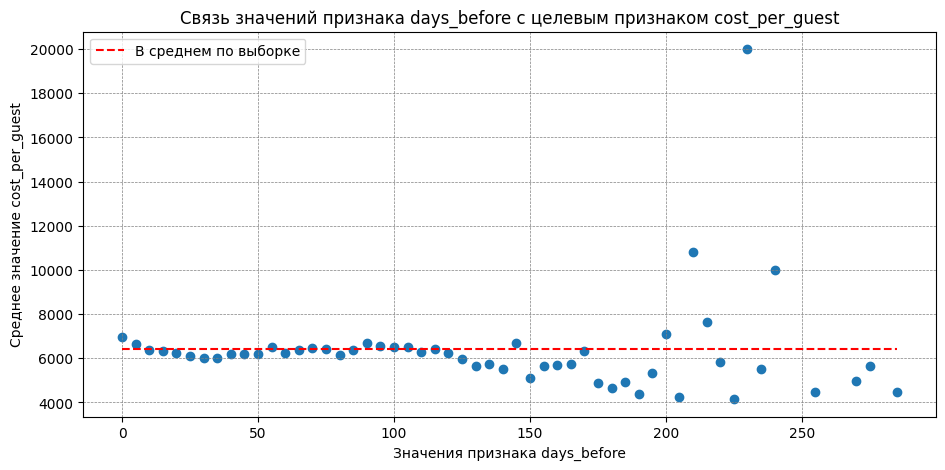

In [62]:
# Посмотрим связь стоимости и количества дней от бронирования до заезда
show_target_dependence(df_train,
                       factor='days_before',
                       target='cost_per_guest',
                       is_cat = False)

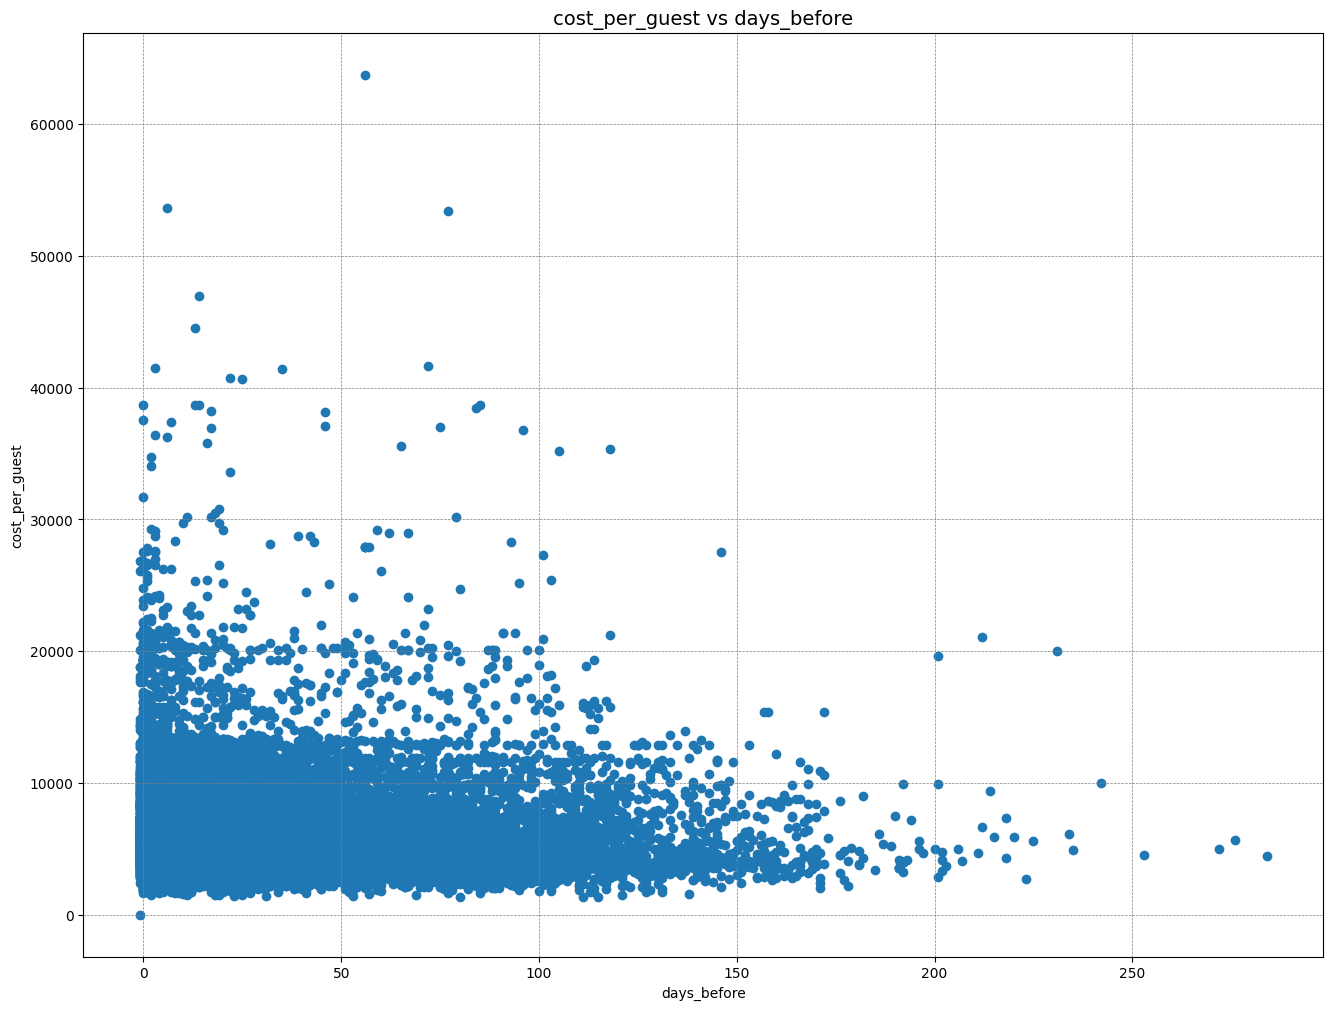

In [63]:
# Визуализируем зависимость по всем точкам
plt.figure(figsize=(16,12))
plt.grid(color='gray', linewidth = 0.5, linestyle = '--', which='both')
plt.title('cost_per_guest vs days_before', fontsize=14)
#plt.yticks(range(0, 1801, 50))
#plt.xticks(range(0, 61, 1), rotation=90)
plt.ylabel('cost_per_guest')
plt.xlabel('days_before')
plt.scatter(df_train['days_before'],
            df_train['cost_per_guest'])
plt.show()

#### Способ оплаты

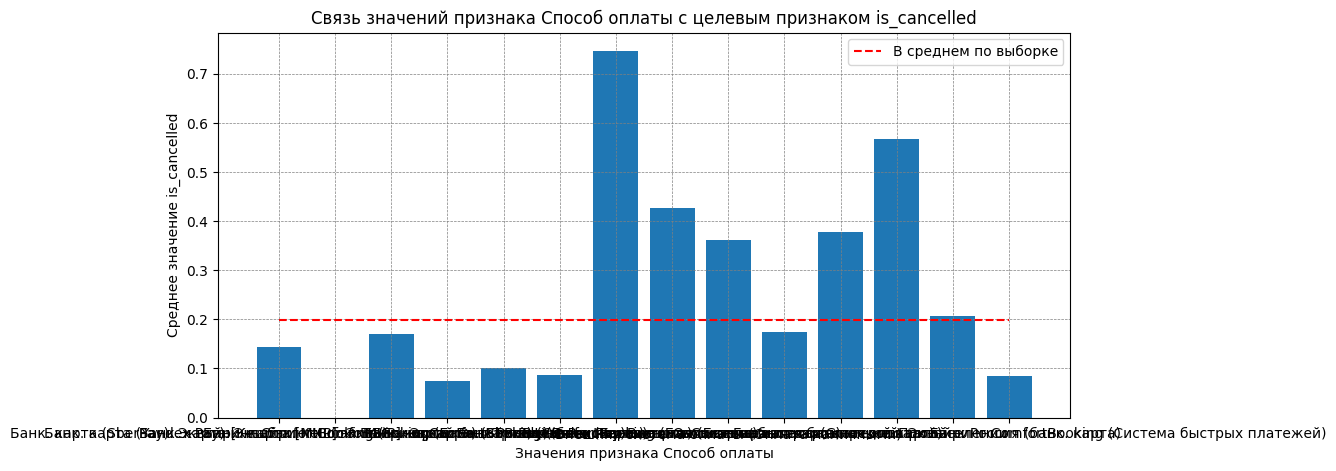

In [64]:
# Посмотрим связь стоимости и количества дней от бронирования до заезда
show_target_dependence(df_train,
                       factor='Способ оплаты',
                       target='is_cancelled',
                       is_cat = True)

In [65]:
# Посмотрим, какие имеются значения
df_train['Способ оплаты'].value_counts()

Способ оплаты
Банк. карта: Банк Россия (банк. карта)                                           13747
Отложенная электронная оплата: Банк Россия (банк. карта)                          4128
Система быстрых платежей: Эквайринг ComfortBooking (Система быстрых платежей)     2539
Внешняя система оплаты (С предоплатой)                                            1875
Банк. карта [Кешбэк. МИР]: Эквайринг TravelLine Pro (Банк. карта)                 1614
Гарантия банковской картой                                                         876
При заселении                                                                      704
Внешняя система оплаты                                                             332
Банк. карта [Кешбэк. МИР]: Эквайринг ComfortBooking (Банк. карта)                  170
Внешняя система оплаты (Оплата наличными)                                           69
Банк. карта: Эквайринг ComfortBooking (Банк. карта)                                 58
Внешняя система оплаты (Банко

In [66]:
# Укрупним категории
def payment_method_cat(payment_method):
    if ((payment_method == 'Отложенная электронная оплата: Банк Россия (банк. карта)')
        or (payment_method == 'Внешняя система оплаты')):
        return 'cat_1'
    elif ((payment_method == 'Гарантия банковской картой')
        or (payment_method == 'Внешняя система оплаты (Оплата наличными)')
        or (payment_method == 'Внешняя система оплаты (Банковская карта)')):
        return 'cat_2'
    elif ((payment_method == 'При заселении')
        or (payment_method == 'Внешняя система оплаты (С предоплатой)')
        or (payment_method == 'Банк. карта [Кешбэк. МИР]: Эквайринг ComfortBooking (Банк. карта)')
        or (payment_method == 'Банк. карта (Yandex Pay): Эквайринг ComfortBooking (Банк. карта) (Yandex Pay)')
        or (payment_method == 'Банк. карта (SberPay): Эквайринг ComfortBooking (Банк. карта) (SberPay)') ):
        return 'cat_3'
    else:
        return 'cat_4'
df_train['pay_cat'] = df_train['Способ оплаты'].apply(payment_method_cat)
df_train['pay_cat'].value_counts(dropna=False)

pay_cat
cat_4    17958
cat_1     4460
cat_3     2757
cat_2      999
Name: count, dtype: int64

In [67]:
# Аналогично для тестовой выборки
df_test['pay_cat'] = df_test['Способ оплаты'].apply(payment_method_cat)
df_test['pay_cat'].value_counts(dropna=False)

pay_cat
cat_4    7793
cat_1    1876
cat_3    1139
cat_2     410
Name: count, dtype: int64

#### Источник

In [68]:
# Посмотрим, как количество бронирований
df_train['Источник'].value_counts()

Источник
Официальный сайт                    21077
Бронирование из экстранета           1306
Яндекс.Путешествия                   1132
ostrovok.ru                           733
booking.com                           629
Программа лояльности                  618
booking.com (Booking.com)             205
Bronevik.com(new)                     141
OneTwoTrip                            141
Cuva                                   34
Zabroniryi.ru                          24
Bronevik.com/Bro.Online                21
Alean.ru (03.02.2022-31.01.2023)       21
Acase.ru (ООО "ПРАНДИУМ")              17
101hotels.com                          16
Acase.ru (ООО "АКАДЕМ-ОНЛАЙН")         15
Alean.ru (16.01.2023-06.09.2024)       10
ВКонтакте                               8
Acase.ru (ООО "КАЛЕЙДОСКОП")            5
expedia.com (A-Hotels.com)              5
Ozon                                    4
Тинькофф Путешествия                    4
Otello                                  3
Alean.ru (13.10.2023-02.0

In [69]:
sorted(df_train['Источник'].unique())

['101hotels.com',
 'Acase.ru (ООО "АКАДЕМ-ОНЛАЙН")',
 'Acase.ru (ООО "КАЛЕЙДОСКОП")',
 'Acase.ru (ООО "ПРАНДИУМ")',
 'Alean.ru (03.02.2022-31.01.2023)',
 'Alean.ru (13.10.2023-02.06.2025)',
 'Alean.ru (16.01.2023-06.09.2024)',
 'Alean.ru (20.01.2021-31.01.2022)',
 'Alean.ru (31.10.2023-22.06.2025)',
 'Bronevik.com(new)',
 'Bronevik.com/Bro.Online',
 'Cuva',
 'OneTwoTrip',
 'Otello',
 'Ozon',
 'Svoy Hotel',
 'Zabroniryi.ru',
 'booking.com',
 'booking.com (Booking.com)',
 'expedia.com (A-Hotels.com)',
 'ostrovok.ru',
 'Бронирование из экстранета',
 'ВКонтакте',
 'Официальный сайт',
 'Программа лояльности',
 'Тинькофф Путешествия',
 'Яндекс.Путешествия']

In [70]:
# Укрупним категории
def sourse_cat(sourse):
    if sourse in ['Acase.ru (ООО "АКАДЕМ-ОНЛАЙН")',
                  'Acase.ru (ООО "КАЛЕЙДОСКОП")',
                   'Acase.ru (ООО "ПРАНДИУМ")']:
        return 'Acase.ru'
    elif sourse in ['Alean.ru (03.02.2022-31.01.2023)',
                    'Alean.ru (13.10.2023-02.06.2025)',
                    'Alean.ru (16.01.2023-06.09.2024)',
                    'Alean.ru (20.01.2021-31.01.2022)',
                    'Alean.ru (31.10.2023-22.06.2025)']:
        return 'Alean.ru'
    elif sourse in ['Bronevik.com(new)',
                    'Bronevik.com/Bro.Online']:
        return 'Bronevik.com(new)'
    elif sourse in ['booking.com',
                    'booking.com (Booking.com)']:
        return 'booking.com'
    else:
        return sourse
df_train['sourse'] = df_train['Источник'].apply(sourse_cat)
df_test['sourse'] = df_test['Источник'].apply(sourse_cat)

In [71]:
df_train['sourse'].value_counts()

sourse
Официальный сайт              21077
Бронирование из экстранета     1306
Яндекс.Путешествия             1132
booking.com                     834
ostrovok.ru                     733
Программа лояльности            618
Bronevik.com(new)               162
OneTwoTrip                      141
Acase.ru                         37
Alean.ru                         35
Cuva                             34
Zabroniryi.ru                    24
101hotels.com                    16
ВКонтакте                         8
expedia.com (A-Hotels.com)        5
Тинькофф Путешествия              4
Ozon                              4
Otello                            3
Svoy Hotel                        1
Name: count, dtype: int64

Дополнительно укрупним категории, объединив в одну последние 6 источников, когда будем работать с нейронной сетью, чтоб при кросс-валидации количество признаков совпадало с количеством нейронов.

#### Категория номера

In [72]:
# Посмотрим, как количество бронирований
# с разными категориями номера
df_train['room_cats'] = df_train['Категория номера'].str.split('\n')
df_train['room_cats'].value_counts()

room_cats
[Номер «Стандарт»]                                                                                                                                     16872
[Номер «Студия»]                                                                                                                                        4929
[Апартаменты с 2 спальнями с отдельным входом]                                                                                                          1957
[Номер «Люкс»]                                                                                                                                           759
[Коттедж с 2 спальнями]                                                                                                                                  720
[Коттедж с 3 спальнями]                                                                                                                                  676
[1. Номер «Стандарт», 2. Номер «Стандарт»]      

In [73]:
# Укрупним категории
def room_cat(room_cats):
    out_room_cats = []
    if len(room_cats) > 1:       
        for room in room_cats:
            out_room_cats.append(room[3:])
        return str(list(set(out_room_cats)))[1:-1]
    else:
        return str(room_cats)[1:-1]
df_train['room_cats'] = df_train['room_cats'].apply(room_cat)
df_train['room_cats'].value_counts()

room_cats
'Номер «Стандарт»'                                                          17048
'Номер «Студия»'                                                             4929
'Апартаменты с 2 спальнями с отдельным входом'                               1976
'Номер «Люкс»'                                                                766
'Коттедж с 2 спальнями'                                                       723
'Коттедж с 3 спальнями'                                                       683
'Номер «Стандарт» для маломобильных групп населения'                           25
'Номер «Стандарт»', 'Номер «Люкс»'                                              7
'Номер «Люкс»', 'Номер «Стандарт»'                                              5
'Коттедж с 2 спальнями', 'Коттедж с 3 спальнями'                                5
'Номер «Стандарт»', 'Коттедж с 3 спальнями'                                     3
'Номер «Стандарт» для маломобильных групп населения', 'Номер «Стандарт»'        2
'Номер

In [74]:
df_test['room_cats'] = df_test['Категория номера'].str.split('\n')
df_test['room_cats'] = df_test['room_cats'].apply(room_cat)
df_test['room_cats'].value_counts()

room_cats
'Номер «Стандарт»'                                                                    7252
'Номер «Студия»'                                                                      2127
'Апартаменты с 2 спальнями с отдельным входом'                                         878
'Номер «Люкс»'                                                                         343
'Коттедж с 2 спальнями'                                                                319
'Коттедж с 3 спальнями'                                                                267
'Номер «Стандарт» для маломобильных групп населения'                                    18
'Номер «Люкс»', 'Номер «Стандарт»'                                                       5
'Номер «Стандарт»', 'Номер «Люкс»'                                                       3
'Номер «Стандарт»', 'Коттедж с 3 спальнями'                                              2
'Номер «Стандарт»', 'Апартаменты с 2 спальнями с отдельным входом'              

In [75]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26174 entries, 0 to 26173
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   № брони              26174 non-null  object        
 1   Номеров              26174 non-null  int64         
 2   Стоимость            26174 non-null  float64       
 3   Внесена предоплата   26174 non-null  int64         
 4   Способ оплаты        26174 non-null  object        
 5   Дата бронирования    26174 non-null  datetime64[ns]
 6   Дата отмены          5192 non-null   datetime64[ns]
 7   Заезд                26174 non-null  datetime64[ns]
 8   Ночей                26174 non-null  int64         
 9   Выезд                26174 non-null  datetime64[ns]
 10  Источник             26174 non-null  object        
 11  Статус брони         26174 non-null  object        
 12  Категория номера     26174 non-null  object        
 13  Гостей               26174 non-

In [76]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11218 entries, 0 to 11217
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   № брони             11218 non-null  object        
 1   Номеров             11218 non-null  int64         
 2   Стоимость           11218 non-null  float64       
 3   Внесена предоплата  11218 non-null  int64         
 4   Способ оплаты       11218 non-null  object        
 5   Дата бронирования   11218 non-null  datetime64[ns]
 6   Заезд               11218 non-null  datetime64[ns]
 7   Ночей               11218 non-null  int64         
 8   Выезд               11218 non-null  datetime64[ns]
 9   Источник            11218 non-null  object        
 10  Категория номера    11218 non-null  object        
 11  Гостей              11218 non-null  int64         
 12  Гостиница           11218 non-null  int64         
 13  cost_per_guest      11218 non-null  float64   

In [77]:
df_train.columns

Index(['№ брони', 'Номеров', 'Стоимость', 'Внесена предоплата',
       'Способ оплаты', 'Дата бронирования', 'Дата отмены', 'Заезд', 'Ночей',
       'Выезд', 'Источник', 'Статус брони', 'Категория номера', 'Гостей',
       'Гостиница', 'is_cancelled', 'cost_per_night', 'cost_per_room-night',
       'cost_per_guest', 'year_month', 'month', 'dow', 'day', 'load',
       'days_before', 'pay_cat', 'sourse', 'room_cats'],
      dtype='object')

In [78]:
# Избавимся от лишних столбцов и изменим типы
df_train.drop(
       ['№ брони', 'Способ оплаты', 'Дата бронирования', 'Дата отмены', 'Заезд',
       'Выезд', 'Источник', 'Категория номера', 'year_month',
       'cost_per_night', 'cost_per_room-night', 'Статус брони'],
    axis=1,
    inplace=True
)
df_train['Гостиница'] = df_train['Гостиница'].astype(str)
df_train['month'] = df_train['month'].map(MONTH_NUMBERS)
df_train['dow'] = df_train['dow'].map(DOW_NUMBERS)

In [79]:
# Избавимся от лишних столбцов и изменим типы
df_test.drop(
       ['№ брони', 'Способ оплаты', 'Дата бронирования', 'Заезд',
       'Выезд', 'Источник', 'Категория номера', 'year_month'],
    axis=1,
    inplace=True
)
df_test['Гостиница'] = df_test['Гостиница'].astype(str)
df_test['month'] = df_test['month'].map(MONTH_NUMBERS)
df_test['dow'] = df_test['dow'].map(DOW_NUMBERS)

In [81]:
df_temp = pd.read_csv('df_with_temp_and_infl.csv')

In [82]:
# Добавим температуру, ключевую ставку и инфляцию
df_train['temp'] = df_temp['temp']
df_train['temp'] = df_train['temp'].fillna(method='ffill')
df_train['key_tax'] = df_temp['Ключевая ставка, % годовых']
df_train['inflation'] = df_temp['Инфляция, % г/г']

In [83]:
# Добавим температуру, ключевую ставку и инфляцию
df_test['temp'] = df_temp['temp']
df_test['temp'] = df_test['temp'].fillna(method='ffill')
df_test['key_tax'] = df_temp['Ключевая ставка, % годовых']
df_test['inflation'] = df_temp['Инфляция, % г/г']

In [84]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26174 entries, 0 to 26173
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Номеров             26174 non-null  int64  
 1   Стоимость           26174 non-null  float64
 2   Внесена предоплата  26174 non-null  int64  
 3   Ночей               26174 non-null  int64  
 4   Гостей              26174 non-null  int64  
 5   Гостиница           26174 non-null  object 
 6   is_cancelled        26174 non-null  int32  
 7   cost_per_guest      26174 non-null  float64
 8   month               26174 non-null  object 
 9   dow                 26174 non-null  object 
 10  day                 26174 non-null  int32  
 11  load                26174 non-null  object 
 12  days_before         26174 non-null  int64  
 13  pay_cat             26174 non-null  object 
 14  sourse              26174 non-null  object 
 15  room_cats           26174 non-null  object 
 16  temp

In [85]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11218 entries, 0 to 11217
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Номеров             11218 non-null  int64  
 1   Стоимость           11218 non-null  float64
 2   Внесена предоплата  11218 non-null  int64  
 3   Ночей               11218 non-null  int64  
 4   Гостей              11218 non-null  int64  
 5   Гостиница           11218 non-null  object 
 6   cost_per_guest      11218 non-null  float64
 7   month               11218 non-null  object 
 8   dow                 11218 non-null  object 
 9   day                 11218 non-null  int32  
 10  load                11218 non-null  object 
 11  days_before         11218 non-null  int64  
 12  pay_cat             11218 non-null  object 
 13  sourse              11218 non-null  object 
 14  room_cats           11218 non-null  object 
 15  temp                11218 non-null  float64
 16  key_

In [ ]:
df_train.to_csv('train_final.csv', index=False)
df_test.to_csv('test_final.csv', index=False)

#### Корреляционный анализ

In [86]:
# Воспользуемся библиотекой Phik для построения матрицы корреляции признаков
cor_matrix = df_train.phik_matrix(
    interval_cols=['Номеров', 'Стоимость', 'Внесена предоплата', 'Ночей', 'Гостей',
       'cost_per_guest', 'day', 'days_before', 'temp', 'key_tax', 'inflation']
)

In [87]:
cor_matrix['is_cancelled'].sort_values(ascending=False)

is_cancelled          1.000000
pay_cat               0.655884
sourse                0.245736
days_before           0.194682
inflation             0.084757
Внесена предоплата    0.073158
Ночей                 0.063178
key_tax               0.044552
Номеров               0.041689
Гостей                0.039306
Стоимость             0.037246
room_cats             0.035766
cost_per_guest        0.033217
Гостиница             0.032797
day                   0.030381
month                 0.024366
dow                   0.021826
temp                  0.013452
load                  0.003481
Name: is_cancelled, dtype: float64

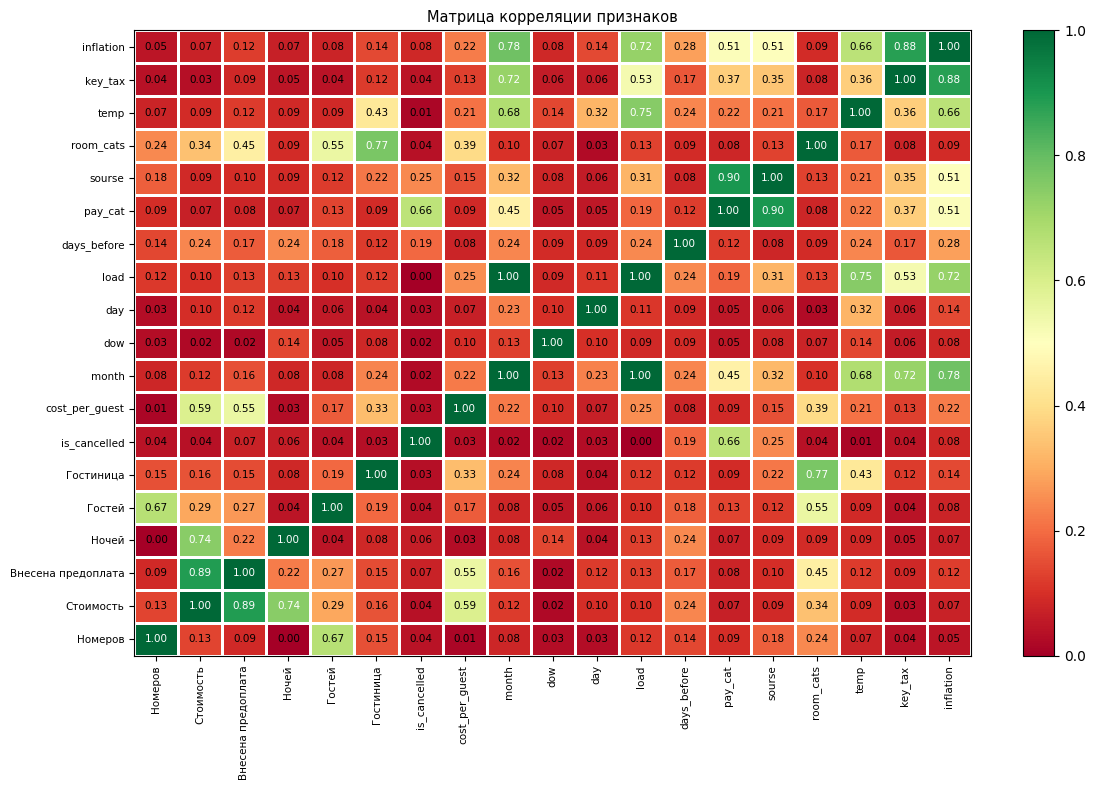

In [88]:
zvalues = cor_matrix.values
xlabels = cor_matrix.columns
ylabels = cor_matrix.index
plot_correlation_matrix(
    zvalues,
    x_labels=xlabels,
    y_labels=ylabels,
    vmin=0,
    vmax=1,
    title='Матрица корреляции признаков',
    identity_layout=False,
    fontsize_factor=0.75,
    figsize=(12,8)
)

По данным корреляции можно сделать выводы:
- признак `gender` никак не связан с целевым, избавимся от него при подготовке данных к моделированию,
- признак `MonthlyCharges` коррелируют с несколькими другими признаками, при этом сильно связан с целевым, поэтому оставим его.

## Подготовка набора данных для моделирования

### Разделение признаков

In [89]:
train = df_train.copy()
test = df_test.copy()

In [90]:
df_train.columns

Index(['Номеров', 'Стоимость', 'Внесена предоплата', 'Ночей', 'Гостей',
       'Гостиница', 'is_cancelled', 'cost_per_guest', 'month', 'dow', 'day',
       'load', 'days_before', 'pay_cat', 'sourse', 'room_cats', 'temp',
       'key_tax', 'inflation'],
      dtype='object')

In [91]:
# Разделим признаки
X = ['Номеров', 'Стоимость', 'Внесена предоплата', 'Ночей', 'Гостей',
     'Гостиница', 'cost_per_guest', 'month',
     'dow', 'day', 'load', 'days_before', 'pay_cat', 'sourse', 'room_cats',
     'temp', 'key_tax', 'inflation']
y = ['is_cancelled']

In [92]:
# Составим список категориальных признаков
cat_features = train[X].select_dtypes(include='object').columns.to_list()
cat_features

['Гостиница', 'month', 'dow', 'load', 'pay_cat', 'sourse', 'room_cats']

In [93]:
# Составим список числовых признаков
num_features = (
    train[X]
    .select_dtypes(include=['int64', 'int32', 'float32', 'float64'])
    .columns.to_list()
)
num_features

['Номеров',
 'Стоимость',
 'Внесена предоплата',
 'Ночей',
 'Гостей',
 'cost_per_guest',
 'day',
 'days_before',
 'temp',
 'key_tax',
 'inflation']

Для решения поставленной задачи будем использовать модель случайного леса, классификаторы на основе градиентного бустинга из библиотеки catboost и библиотеки LightGBM, а также полносвязную нейронную сеть.
Для оценки качества и выбора модели будем использовать площадь под ROC (roc auc), чтоб понять, насколько качественно модель выполняет разделение классов.

В дальнейшем, чтоб максимизировать долю правильных предсказаний при разумной доле ошибочных предсказаний подберём значение порога для выбранной модели с максимальной площадью под ROC.

## Обучение моделей

### Константная модель

In [75]:
# Создадим и обучим константную модель, которая всегда возвращает одно значение
dummy_clf = DummyClassifier(strategy='prior', constant=None, random_state=RANDOM_STATE)
dummy_clf.fit(train[X], train[y])

DummyClassifier(random_state=20231212)

In [76]:
# Проверим качество. roc_auc
predicted_dummy = dummy_clf.predict_proba(test[X])[:, 1]
roc_auc_score(test[y], predicted_dummy)

0.5

### Модель на основе случайного леса

In [94]:
# Преобразователь признаков для модели случайного леса и модели LightGBM
try:
    col_transformer_forest = make_column_transformer(
        (
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            cat_features,
        ),
        remainder='passthrough',
    verbose_feature_names_out=False
    )
except:
    col_transformer_forest = make_column_transformer(
        (
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            cat_features,
        ),
        remainder='passthrough'
    )

In [203]:
# Пайплайн для модели случайного леса
model_forest = RandomForestClassifier(
    random_state=RANDOM_STATE, class_weight='balanced'
)
pipline_rf = make_pipeline(col_transformer_forest, model_forest)

param_grid_rf = {
    'randomforestclassifier__n_estimators': range(10, 101, 1),
    'randomforestclassifier__max_depth': range(2, 21, 1),
    'randomforestclassifier__min_samples_split': np.arange(0.02, 0.8, step=0.01),
    'randomforestclassifier__min_samples_leaf': range(2, 11, 1),
}

# будем использовать RandomizedSearchCV, он работает быстрее
gs_rf = RandomizedSearchCV(
    pipline_rf,
    param_distributions=param_grid_rf,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    random_state=RANDOM_STATE,
)

# Модель на основе случайного леса
gs_rf.fit(train[X], train[y].values.ravel())
gs_rf_best_score = gs_rf.best_score_
gs_rf_best_params = gs_rf.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_rf_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_rf_best_params}')

best_score: 0.8385319356187846
best_params: {'randomforestclassifier__n_estimators': 48, 'randomforestclassifier__min_samples_split': 0.09999999999999999, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__max_depth': 12}


In [204]:
submission = pd.Series(gs_rf.predict(test[X]))
submission.to_csv('submit_5.csv', index=False, header=False)

### Градиентный бустинг (библиотека  LightGBM)

In [95]:
# Данные для модели
try:
    X_train_LGBM = pd.DataFrame(
        col_transformer_forest.fit_transform(train[X]),
        columns=col_transformer_forest.get_feature_names_out()
    )
    X_test_LGBM = pd.DataFrame(
        col_transformer_forest.transform(test[X]),
        columns=col_transformer_forest.get_feature_names_out()
    )
except:
    X_train_LGBM = pd.DataFrame(
        col_transformer_forest.fit_transform(train[X]),
        columns = col_transformer_forest.transformers_[0][2] \
                + col_transformer_forest.transformers_[1][2]
    )
    X_test_LGBM = pd.DataFrame(
        col_transformer_forest.transform(test[X]),
        columns=col_transformer_forest.transformers_[0][2] \
              + col_transformer_forest.transformers_[1][2]
    )

# Модель
lgbm = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')

In [206]:
# Данные для подбора гиперпараметров
grid_param_lgbm = {
    'learning_rate': np.arange(0.001, 0.21, 0.01),
    'reg_lambda': np.arange(0.01, 0.91, 0.05),
}
# Градиентный бустинг (библиотека LightGBM) с ordinal encoding
grid_lgbm = GridSearchCV(
    estimator=lgbm, param_grid=grid_param_lgbm, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_lgbm.fit(X_train_LGBM, train[y].values.ravel())

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {grid_lgbm.best_score_}')
# лучшие гиперпараметры
print(f'best_params: {grid_lgbm.best_params_}')

best_score: 0.8600890812307963
best_params: {'learning_rate': 0.071, 'reg_lambda': 0.31000000000000005}


In [207]:
submission = pd.Series(grid_lgbm.predict(X_test_LGBM))
submission.to_csv('submit_6.csv', index=False, header=False)

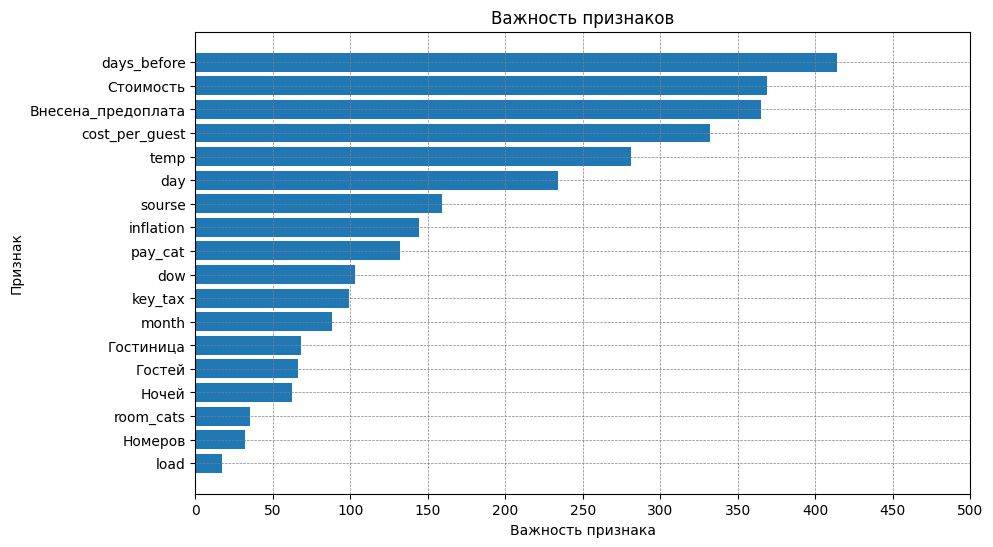

In [211]:
# Проверим важность признаков с точки зрения модели
importances = pd.Series(grid_lgbm.best_estimator_.feature_importances_,
                        index=grid_lgbm.best_estimator_.feature_name_)
plt.figure(figsize=(10, 6))
plt.title('Важность признаков')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.xlim([0, 500])
plt.xticks(np.arange(0, 501, step=50), rotation=0)
plt.grid(color='gray', linewidth = 0.5, linestyle = '--')
plt.barh(y=importances.sort_values().index, width=importances.sort_values())
plt.show()

### Градиентный бустинг (библиотека catboost)

In [212]:
# Модель
cb = CatBoostClassifier(
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    logging_level='Silent',
    early_stopping_rounds=20,
    auto_class_weights='Balanced'
)

In [213]:
# Данные для подбора гиперпараметров
grid_param_cb = {
    'learning_rate': [0.005, 0.01, 0.05],
    'iterations': [2000],
    'max_depth': [6, 10]
}
# Градиентный бустинг (библиотека catboost)
grid_cb = GridSearchCV(
    estimator=cb, param_grid=grid_param_cb, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_cb.fit(train[X], train[y])

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {grid_cb.best_score_}')
# лучшие гиперпараметры
print(f'best_params: {grid_cb.best_params_}')

best_score: 0.8596747413653922
best_params: {'iterations': 2000, 'learning_rate': 0.01, 'max_depth': 6}


In [214]:
submission = pd.Series(grid_cb.predict(test[X]))
submission.to_csv('submit_7.csv', index=False, header=False)

### Полносвязная нейронная сеть

In [133]:
# Определим трансформер для преобразования в тензоры
class to_float_transformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return torch.FloatTensor(X)

In [134]:
train.loc[df_train['sourse'].isin(
    df_train['sourse'].value_counts()[-6:].index), 'sourse'] = 'other'
train['sourse'].value_counts()

sourse
Официальный сайт              21077
Бронирование из экстранета     1306
Яндекс.Путешествия             1132
booking.com                     834
ostrovok.ru                     733
Программа лояльности            618
Bronevik.com(new)               162
OneTwoTrip                      141
Acase.ru                         37
Alean.ru                         35
Cuva                             34
other                            25
Zabroniryi.ru                    24
101hotels.com                    16
Name: count, dtype: int64

In [135]:
test.loc[df_test['sourse'].isin(
    df_train['sourse'].value_counts()[-6:].index), 'sourse'] = 'other'
test['sourse'].value_counts()

sourse
Официальный сайт              9132
Бронирование из экстранета     556
Яндекс.Путешествия             488
booking.com                    343
ostrovok.ru                    274
Программа лояльности           242
OneTwoTrip                      72
Bronevik.com(new)               63
Cuva                            13
Alean.ru                        12
other                            6
Acase.ru                         6
Zabroniryi.ru                    6
101hotels.com                    5
Name: count, dtype: int64

In [136]:
try:
    # Преобразователь признаков для нейронной сети
    col_transformer_net = make_column_transformer(
        (
            OneHotEncoder(drop='first',
                          handle_unknown='ignore',
                          sparse_output=False,
                          dtype='int16'),
            cat_features
        ),
        (
            MinMaxScaler(),
            num_features
        ),
        remainder='passthrough',
        verbose_feature_names_out=False
    )
except:
    col_transformer_net = make_column_transformer(
        (OneHotEncoder(drop='first',
                       handle_unknown='ignore',
                       sparse_output=False,), cat_features),
        (MinMaxScaler(), num_features),
        remainder='passthrough'
    )
X_train_transformed = to_float_transformer().fit_transform(
    col_transformer_net.fit_transform(train[X]))
X_train_transformed.shape

torch.Size([26174, 62])

In [137]:
# Зададим коичество нейронов на входе и на выходе
n_in_neurons = X_train_transformed.shape[1]
n_out_neurons = 1
n_in_neurons

62

In [138]:
# Преобразуем в тензор столбец с целевым признаком
y_train = torch.FloatTensor(train[y].values).flatten()
y_train.shape

torch.Size([26174])

In [139]:
# Зададим устройство, на котором будет работать нейронная сеть
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

В качестве базовой модели возьмём нейронную сеть с одним скрытым слоем.

Параметры сети:
- количество нейронов во входном слое - 18 (по числу признаков),
- количество нейронов в выходном слое - 1,
- количество нейронов в скрытом слое будем перебирать от $\sqrt{60*1} \approx 8$ (примем 8) до $(60+1)*(2/3)=40$ (примем 40) по степеням двойки 8, 16, 32, а также добавим вариант 64,
- функция активации скрытого слоя - ReLU, выходного слоя - Sigmoid,
- инициализация весов модели - по умолчанию,
- функция потерь - бинарная кросс-энтропия, BCELoss,
- метрика - roc_auc.

In [294]:
# Создадим класс для задания архитектуры нейронной сети
class Net_1(nn.Module):
    def __init__(self, n_in_neurons, n_hidden_neurons, n_out_neurons):
        super(Net_1, self).__init__()

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons, n_out_neurons)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        return x

In [141]:
# Определим собственный scorer
def my_auc(net, X, y):
    y_proba = net.predict_proba(X)[:,1]
    return {'auc_roc':roc_auc_score(y, y_proba)}

In [296]:
# Пайплайн для базовой нейронной сети
model_net_1 = NeuralNetBinaryClassifier(Net_1,
                          criterion=nn.BCELoss,
                          optimizer = torch.optim.Adam,
                          max_epochs = 100,
                          threshold=0.5,
                          device=device,
                          verbose=1,
                          lr=5e-3)
pipline_net_1 = make_pipeline(
    col_transformer_net, to_float_transformer(), model_net_1
)

param_grid_net_1 = {
    'neuralnetbinaryclassifier__module__n_in_neurons': [n_in_neurons],
    'neuralnetbinaryclassifier__module__n_hidden_neurons': [8, 16, 32, 64],
    'neuralnetbinaryclassifier__module__n_out_neurons': [n_out_neurons],
    'neuralnetbinaryclassifier__batch_size': [500, 1000]
}

# получается не так много комбинаций гиперпараметров при переборе
# будем использовать GridSearchCV, он работает быстрее
gs_net_1 = GridSearchCV(
    pipline_net_1,
    param_grid=param_grid_net_1,
    scoring=my_auc,
    refit='auc_roc',
    cv=5,
    verbose=1
)

# Нейронная сеть
gs_net_1.fit(train[X], y_train)
gs_net_1_best_score = gs_net_1.best_score_
gs_net_1_best_params = gs_net_1.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_net_1_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_net_1_best_params}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5409       0.8016        0.4784  0.2142
      2        0.4643       0.8016        0.4555  0.2092
      3        0.4460       0.8004        0.4408  0.2154
      4        0.4311       0.8023        0.4270  0.2122
      5        0.4173       0.8056        0.4145  0.4014
      6        0.4059       0.8118        0.4058  0.2012
      7        0.3985       0.8243        0.4009  0.2142
      8        0.3938       0.8333        0.3962  0.2194
      9        0.3889       0.8352        0.3937  0.2342
     10        0.3862       0.8350        0.3927  0.1982
     11        0.3845       0.8352        0.3918  0.1972
     12        0.3832       0.8362        0.3910  0.2002
     13        0.3819       0.8369        0.3902  0.1900
     14        0.3806       0.8367        0.3895  0.2003
     15        0.3794       

      2        0.4799       0.8016        0.4707  0.1982
      3        0.4520       0.8042        0.4410  0.1972
      4        0.4232       0.8066        0.4195  0.2002
      5        0.4039       0.8192        0.4062  0.1964
      6        0.3929       0.8329        0.3994  0.1973
      7        0.3875       0.8350        0.3962  0.1962
      8        0.3847       0.8383        0.3946  0.1922
      9        0.3831       0.8372        0.3936  0.1942
     10        0.3819       0.8376        0.3927  0.1954
     11        0.3809       0.8379        0.3919  0.2012
     12        0.3800       0.8376        0.3911  0.2004
     13        0.3792       0.8386        0.3904  0.1972
     14        0.3784       0.8395        0.3896  0.1973
     15        0.3777       0.8407        0.3889  0.1963
     16        0.3770       0.8419        0.3882  0.1997
     17        0.3763       0.8436        0.3874  0.1992
     18        0.3756       0.8450        0.3865  0.3824
     19        0.3750       0.8

      2        0.4680       0.8016        0.4583  0.2022
      3        0.4457       0.8021        0.4397  0.1932
      4        0.4274       0.8037        0.4235  0.2000
      5        0.4124       0.8087        0.4113  0.1942
      6        0.4023       0.8164        0.4043  0.1962
      7        0.3968       0.8269        0.4007  0.1992
      8        0.3937       0.8357        0.3985  0.1937
      9        0.3917       0.8372        0.3972  0.2022
     10        0.3904       0.8388        0.3963  0.1972
     11        0.3894       0.8381        0.3956  0.1997
     12        0.3886       0.8386        0.3950  0.3745
     13        0.3878       0.8393        0.3944  0.1966
     14        0.3871       0.8403        0.3938  0.1962
     15        0.3864       0.8412        0.3928  0.2017
     16        0.3856       0.8429        0.3921  0.1972
     17        0.3844       0.8438        0.3907  0.2017
     18        0.3833       0.8457        0.3898  0.1993
     19        0.3823       0.8

      2        0.4764       0.8016        0.4690  0.1972
      3        0.4565       0.8018        0.4484  0.1989
      4        0.4326       0.8092        0.4274  0.2041
      5        0.4128       0.8154        0.4114  0.1992
      6        0.3998       0.8274        0.4023  0.3768
      7        0.3934       0.8355        0.3983  0.1952
      8        0.3907       0.8386        0.3964  0.1972
      9        0.3892       0.8412        0.3953  0.1962
     10        0.3881       0.8419        0.3944  0.1962
     11        0.3871       0.8429        0.3935  0.1972
     12        0.3862       0.8436        0.3926  0.1992
     13        0.3854       0.8448        0.3918  0.1972
     14        0.3845       0.8453        0.3910  0.1962
     15        0.3838       0.8462        0.3903  0.1972
     16        0.3831       0.8479        0.3895  0.1932
     17        0.3823       0.8484        0.3888  0.1962
     18        0.3816       0.8484        0.3881  0.1973
     19        0.3809       0.8

      2        0.4755       0.8016        0.4672  0.1992
      3        0.4546       0.8016        0.4523  0.1982
      4        0.4385       0.8042        0.4387  0.1972
      5        0.4236       0.8040        0.4254  0.1962
      6        0.4102       0.8080        0.4145  0.1965
      7        0.4005       0.8147        0.4071  0.2013
      8        0.3946       0.8231        0.4030  0.2033
      9        0.3914       0.8293        0.4008  0.1993
     10        0.3895       0.8329        0.3992  0.1953
     11        0.3881       0.8350        0.3982  0.2002
     12        0.3870       0.8364        0.3975  0.2002
     13        0.3862       0.8376        0.3969  0.1966
     14        0.3855       0.8376        0.3963  0.2006
     15        0.3848       0.8386        0.3958  0.2002
     16        0.3841       0.8386        0.3953  0.2063
     17        0.3835       0.8386        0.3949  0.2022
     18        0.3830       0.8393        0.3946  0.2019
     19        0.3824       0.8

...

     75        0.2781       0.8789        0.3450  0.1651
     76        0.2771       0.8797        0.3446  0.1752
     77        0.2762       0.8799        0.3442  0.1752
     78        0.2754       0.8799        0.3441  0.1722
     79        0.2744       0.8801        0.3437  0.3603
     80        0.2736       0.8804        0.3435  0.1812
     81        0.2728       0.8809        0.3429  0.1822
     82        0.2720       0.8816        0.3424  0.1742
     83        0.2712       0.8811        0.3420  0.1762
     84        0.2705       0.8804        0.3418  0.1772
     85        0.2698       0.8806        0.3418  0.1842
     86        0.2691       0.8809        0.3415  0.1792
     87        0.2684       0.8806        0.3411  0.1752
     88        0.2678       0.8816        0.3410  0.1816
     89        0.2671       0.8818        0.3408  0.1792
     90        0.2666       0.8825        0.3408  0.1812
     91        0.2658       0.8816        0.3403  0.3673
     92        0.2651       0.8

     78        0.2753       0.8789        0.3353  0.1805
     79        0.2746       0.8801        0.3354  0.1802
     80        0.2738       0.8804        0.3356  0.1792
     81        0.2732       0.8797        0.3358  0.1862
     82        0.2726       0.8789        0.3360  0.3773
     83        0.2719       0.8806        0.3359  0.1834
     84        0.2714       0.8799        0.3364  0.1832
     85        0.2708       0.8801        0.3366  0.1772
     86        0.2703       0.8794        0.3369  0.1752
     87        0.2698       0.8801        0.3369  0.1802
     88        0.2692       0.8806        0.3374  0.1672
     89        0.2687       0.8804        0.3376  0.1772
     90        0.2682       0.8806        0.3380  0.1682
     91        0.2675       0.8794        0.3381  0.1702
     92        0.2672       0.8801        0.3385  0.1722
     93        0.2667       0.8806        0.3383  0.1792
     94        0.2661       0.8804        0.3385  0.3693
     95        0.2656       0.8

     83        0.2751       0.8782        0.3464  0.1702
     84        0.2743       0.8777        0.3456  0.1651
     85        0.2734       0.8777        0.3454  0.3510
     86        0.2726       0.8785        0.3457  0.1651
     87        0.2719       0.8787        0.3456  0.1648
     88        0.2711       0.8785        0.3452  0.1712
     89        0.2704       0.8785        0.3450  0.1641
     90        0.2696       0.8794        0.3453  0.1621
     91        0.2689       0.8794        0.3454  0.1641
     92        0.2682       0.8801        0.3449  0.1672
     93        0.2677       0.8799        0.3451  0.1641
     94        0.2670       0.8797        0.3454  0.1641
     95        0.2664       0.8794        0.3449  0.1641
     96        0.2655       0.8797        0.3453  0.3556
     97        0.2648       0.8799        0.3448  0.1617
     98        0.2642       0.8794        0.3453  0.1641
     99        0.2637       0.8789        0.3454  0.1651
    100        0.2629       0.8

     86        0.2785       0.8811        0.3359  0.1802
     87        0.2779       0.8811        0.3357  0.3603
     88        0.2770       0.8816        0.3354  0.1672
     89        0.2764       0.8818        0.3352  0.1782
     90        0.2757       0.8820        0.3353  0.1802
     91        0.2751       0.8818        0.3349  0.1692
     92        0.2744       0.8820        0.3349  0.1752
     93        0.2738       0.8813        0.3347  0.1692
     94        0.2732       0.8816        0.3345  0.1732
     95        0.2727       0.8818        0.3344  0.1682
     96        0.2720       0.8818        0.3344  0.1692
     97        0.2714       0.8811        0.3342  0.1712
     98        0.2709       0.8818        0.3343  0.1692
     99        0.2703       0.8818        0.3344  0.3563
    100        0.2698       0.8830        0.3346  0.1782
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5363       0.8

     87        0.2889       0.8938        0.3109  0.2763
     88        0.2885       0.8938        0.3105  0.2823
     89        0.2881       0.8936        0.3102  0.2763
     90        0.2877       0.8942        0.3102  0.4694
     91        0.2873       0.8944        0.3098  0.2863
     92        0.2870       0.8938        0.3095  0.2923
     93        0.2866       0.8940        0.3092  0.2903
     94        0.2863       0.8944        0.3090  0.2843
     95        0.2860       0.8944        0.3086  0.2783
     96        0.2857       0.8942        0.3084  0.2793
     97        0.2854       0.8944        0.3081  0.2803
     98        0.2851       0.8944        0.3080  0.2794
     99        0.2849       0.8946        0.3079  0.2769
    100        0.2845       0.8946        0.3078  0.2905
best_score: 0.8423078215572181
best_params: {'neuralnetbinaryclassifier__batch_size': 500, 'neuralnetbinaryclassifier__module__n_hidden_neurons': 16, 'neuralnetbinaryclassifier__module__n_in_neurons': 6

Лучшее значение, которое удалось добиться с базовой моделью - 0.8423 (16 нейронов в скрытом слое). Попробуем добавить ещё слой.

In [298]:
# Создадим класс для задания архитектуры нейронной сети
class Net_2(nn.Module):
    def __init__(
        self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons
    ):
        super(Net_2, self).__init__()
        self.n_in_neurons = n_in_neurons
        self.n_hidden_neurons_1 = n_hidden_neurons_1,
        self.n_hidden_neurons_2 = n_hidden_neurons_2,
        self.n_out_neurons = n_out_neurons

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)
        self.act3 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        return x

In [299]:
# Пайплайн для нейронной сети с двумя слоями
model_net_2 = NeuralNetBinaryClassifier(Net_2,
                          criterion=nn.BCELoss,
                          optimizer = torch.optim.Adam,
                          max_epochs = 100,
                          threshold=0.5,
                          device=device,
                          verbose=0,
                          lr=5e-3)
pipline_net_2 = make_pipeline(
    col_transformer_net, to_float_transformer(), model_net_2
)

param_grid_net_2 = {
    'neuralnetbinaryclassifier__module__n_in_neurons': [n_in_neurons],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_1': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_2': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_out_neurons': [n_out_neurons],
    'neuralnetbinaryclassifier__batch_size': [500]
}

# получается не так много комбинаций гиперпараметров при переборе
# будем использовать GridSearchCV
gs_net_2 = GridSearchCV(
    pipline_net_2,
    param_grid=param_grid_net_2,
    scoring=my_auc,
    refit='auc_roc',
    cv=5,
    verbose=2
)

# Нейронная сеть
gs_net_2.fit(train[X], y_train)
gs_net_2_best_score = gs_net_2.best_score_
gs_net_2_best_params = gs_net_2.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_net_2_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_net_2_best_params}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.0s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  21.6s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  21.2s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassi

[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=32, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.0s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  21.4s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  21.4s
[CV] END neuralnetbinaryclassifier__batch_size=500, neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclas

Удалось улучшить результат. Наилучшее достигнутое значение метрики 0.8472 (в первом слое 8 нейронов, во втором слое - 32). Попробуем добавить batch normalization к модели с двумя слоями.

In [304]:
submission = pd.Series(gs_net_2.predict(test[X]))
submission.to_csv('submit_9.csv', index=False, header=False)

C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:228: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [305]:
# Создадим класс для задания архитектуры нейронной сети
class Net_2_batch(nn.Module):
    def __init__(
        self, n_in_neurons, n_hidden_neurons_1, n_hidden_neurons_2, n_out_neurons
    ):
        super(Net_2_batch, self).__init__()
        self.n_in_neurons = n_in_neurons
        self.n_hidden_neurons_1 = n_hidden_neurons_1,
        self.n_hidden_neurons_2 = n_hidden_neurons_2,
        self.n_out_neurons = n_out_neurons

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.bn1 = nn.BatchNorm1d(n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_out_neurons)
        self.act3 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        return x

In [306]:
# Пайплайн для нейронной сети с двумя слоями и batch normalization
model_net_2_batch = NeuralNetBinaryClassifier(Net_2_batch,
                          criterion=nn.BCELoss,
                          optimizer = torch.optim.Adam,
                          max_epochs = 200,
                          batch_size = 500,
                          threshold=0.5,
                          device=device,
                          verbose=0,
                          lr=5e-3)
pipline_net_2_batch = make_pipeline(
    col_transformer_net, to_float_transformer(), model_net_2_batch
)

param_grid_net_2_batch = {
    'neuralnetbinaryclassifier__module__n_in_neurons': [n_in_neurons],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_1': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_2': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_out_neurons': [n_out_neurons]
}

# получается не так много комбинаций гиперпараметров при переборе
# будем использовать GridSearchCV
gs_net_2_batch = GridSearchCV(
    pipline_net_2_batch,
    param_grid=param_grid_net_2_batch,
    scoring=my_auc,
    refit='auc_roc',
    cv=5,
    verbose=2
)

# Нейронная сеть
gs_net_2_batch.fit(train[X], y_train)
gs_net_2_batch_best_score = gs_net_2_batch.best_score_
gs_net_2_batch_best_params = gs_net_2_batch.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_net_2_batch_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_net_2_batch_best_params}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  45.1s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  44.6s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  43.9s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__

[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  47.5s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  48.9s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  45.9s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_in_neurons=60, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  47.3s
[CV] END n

Результат не удалось улучшить. Лучшее значение 0.8368 достигнуто с количеством нейронов в первом скрытом слое 8, во втором слое - 8). Попробуем добавить ещё слой без batch normalization.

In [131]:
# Создадим класс для задания архитектуры нейронной сети
class Net_3(nn.Module):
    def __init__(
        self, n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_hidden_neurons_3,
        n_out_neurons
    ):
        super(Net_3, self).__init__()
        self.n_in_neurons = n_in_neurons
        self.n_hidden_neurons_1 = n_hidden_neurons_1,
        self.n_hidden_neurons_2 = n_hidden_neurons_2,
        self.n_hidden_neurons_3 = n_hidden_neurons_3,
        self.n_out_neurons = n_out_neurons

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
        self.act3 = nn.ReLU()

        self.fc4 = nn.Linear(n_hidden_neurons_3, n_out_neurons)
        self.act4 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        x = self.fc4(x)
        x = self.act4(x)

        return x

In [142]:
# Пайплайн для нейронной сети с двумя слоями
model_net_3 = NeuralNetBinaryClassifier(Net_3,
                          criterion=nn.BCELoss,
                          optimizer = torch.optim.Adam,
                          max_epochs = 100,
                          batch_size = 500,
                          threshold=0.5,
                          device=device,
                          verbose=0,
                          lr=5e-3)
pipline_net_3 = make_pipeline(
    col_transformer_net, to_float_transformer(), model_net_3
)

param_grid_net_3 = {
    'neuralnetbinaryclassifier__module__n_in_neurons': [n_in_neurons],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_1': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_2': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_3': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_out_neurons': [n_out_neurons]
}

# получается не так много комбинаций гиперпараметров при переборе
# будем использовать GridSearchCV
gs_net_3 = GridSearchCV(
    pipline_net_3,
    param_grid=param_grid_net_3,
    scoring=my_auc,
    refit='auc_roc',
    cv=5,
    verbose=2
)

# Нейронная сеть
gs_net_3.fit(train[X], y_train)
gs_net_3_best_score = gs_net_3.best_score_
gs_net_3_best_params = gs_net_3.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_net_3_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_net_3_best_params}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=   2.5s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.2s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  21.9s
[CV] END neuralnetbinaryclass

[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.3s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.4s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=   0.0s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclas

[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  23.1s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  23.2s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  23.2s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinarycla

[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=32, neuralnetbinaryclassifier__module__n_hidden_neurons_3=16, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.1s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=32, neuralnetbinaryclassifier__module__n_hidden_neurons_3=16, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=   0.0s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinaryclassifier__module__n_hidden_neurons_2=32, neuralnetbinaryclassifier__module__n_hidden_neurons_3=32, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=   0.0s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=16, neuralnetbinary

[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=16, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.7s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=16, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.4s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinaryclassifier__module__n_hidden_neurons_2=16, neuralnetbinaryclassifier__module__n_hidden_neurons_3=16, neuralnetbinaryclassifier__module__n_in_neurons=62, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  22.6s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=32, neuralnetbinary

C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
54 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\pipeline.py", line 427, i

best_score: nan
best_params: {'neuralnetbinaryclassifier__module__n_hidden_neurons_1': 8, 'neuralnetbinaryclassifier__module__n_hidden_neurons_2': 8, 'neuralnetbinaryclassifier__module__n_hidden_neurons_3': 8, 'neuralnetbinaryclassifier__module__n_in_neurons': 62, 'neuralnetbinaryclassifier__module__n_out_neurons': 1}


Результат удалось улучшить. Лучшее значение 0,8359 достигнуто с количеством нейронов в первом скрытом слое 32, во втором слое - 8, в третьем слое - 8). Попробуем добавить слой batch normalization.

In [304]:
submission = pd.Series(gs_net_2.predict(test[X]))
submission.to_csv('submit_10.csv', index=False, header=False)

C:\Users\Дмитрий\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:228: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [98]:
# Создадим класс для задания архитектуры нейронной сети
class Net_3_batch(nn.Module):
    def __init__(
        self, n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2,
        n_hidden_neurons_3,
        n_out_neurons
    ):
        super(Net_3_batch, self).__init__()
        self.n_in_neurons = n_in_neurons
        self.n_hidden_neurons_1 = n_hidden_neurons_1,
        self.n_hidden_neurons_2 = n_hidden_neurons_2,
        self.n_hidden_neurons_3 = n_hidden_neurons_3,
        self.n_out_neurons = n_out_neurons

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.bn1 = nn.BatchNorm1d(n_hidden_neurons_1)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
        self.act2 = nn.ReLU()

        self.fc3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
        self.act3 = nn.ReLU()

        self.fc4 = nn.Linear(n_hidden_neurons_3, n_out_neurons)
        self.act4 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        x = self.fc3(x)
        x = self.act3(x)

        x = self.fc4(x)
        x = self.act4(x)

        return x

In [99]:
# Пайплайн для нейронной сети с тремя слоями и батч-нормализацией
model_net_3_batch = NeuralNetBinaryClassifier(Net_3_batch,
                          criterion=nn.BCELoss,
                          optimizer = torch.optim.Adam,
                          max_epochs = 200,
                          batch_size = 100,
                          threshold=0.5,
                          device=device,
                          verbose=0,
                          lr=1e-4)
pipline_net_3_batch = make_pipeline(
    col_transformer_net, to_float_transformer(), model_net_3_batch
)

param_grid_net_3_batch = {
    'neuralnetbinaryclassifier__module__n_in_neurons': [n_in_neurons],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_1': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_2': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_hidden_neurons_3': [8, 16, 32],
    'neuralnetbinaryclassifier__module__n_out_neurons': [n_out_neurons]
}

# получается не так много комбинаций гиперпараметров при переборе
# будем использовать GridSearchCV
gs_net_3_batch = GridSearchCV(
    pipline_net_3_batch,
    param_grid=param_grid_net_3_batch,
    scoring=my_auc, # для экономии памяти
    refit='auc_roc',
    cv=4,
    verbose=2
)

# Нейронная сеть
gs_net_3_batch.fit(train[X], y_train)
gs_net_3_batch_best_score = gs_net_3_batch.best_score_
gs_net_3_batch_best_params = gs_net_3_batch.best_params_

# лучшее значение roc_auc на кросс-валидации
print(f'best_score: {gs_net_3_batch_best_score}')
# лучшие гиперпараметры
print(f'best_params: {gs_net_3_batch_best_params}')

Fitting 4 folds for each of 27 candidates, totalling 108 fits
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=26, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  29.2s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=26, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  29.4s
[CV] END neuralnetbinaryclassifier__module__n_hidden_neurons_1=8, neuralnetbinaryclassifier__module__n_hidden_neurons_2=8, neuralnetbinaryclassifier__module__n_hidden_neurons_3=8, neuralnetbinaryclassifier__module__n_in_neurons=26, neuralnetbinaryclassifier__module__n_out_neurons=1; total time=  40.9s
[CV] END neuralnetbinaryclass

Результат не удалось улучшить. Лучшее значение 0,8321 достигнуто с количеством нейронов в первом скрытом слое 16, во втором слое - 8, в третьем скрытом слое - 8.

In [101]:
# Очитсим оперативную память
del model_net_1, pipline_net_1, gs_net_1, gs_net_1_best_score, gs_net_1_best_params, model_net_2, pipline_net_2, \
gs_net_2, gs_net_2_best_score, gs_net_2_best_params, model_net_2_batch, pipline_net_2_batch, gs_net_2_batch, \
gs_net_2_batch_best_score, gs_net_2_batch_best_params, model_net_3_batch, pipline_net_3_batch, gs_net_3_batch, \
gs_net_3_batch_best_score, gs_net_3_batch_best_params
gc.collect()

83

#### Кластеризация

In [97]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=10)
X_tsne = tsne.fit_transform(X_train_LGBM[:, :-2])

In [99]:
X_tsne.shape

(26174, 2)

In [ ]:
from sklearn.cluster import DBSCAN

кластеров: 7


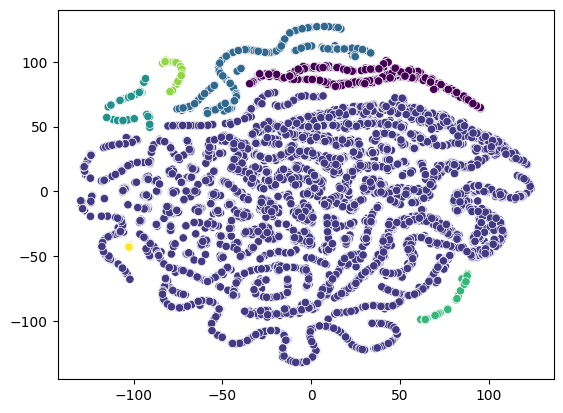

In [130]:
dbscan = DBSCAN(eps=9, min_samples=10).fit(X_tsne)
labels = dbscan.labels_

uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], c=labels)
plt.show()

## Выбор модели

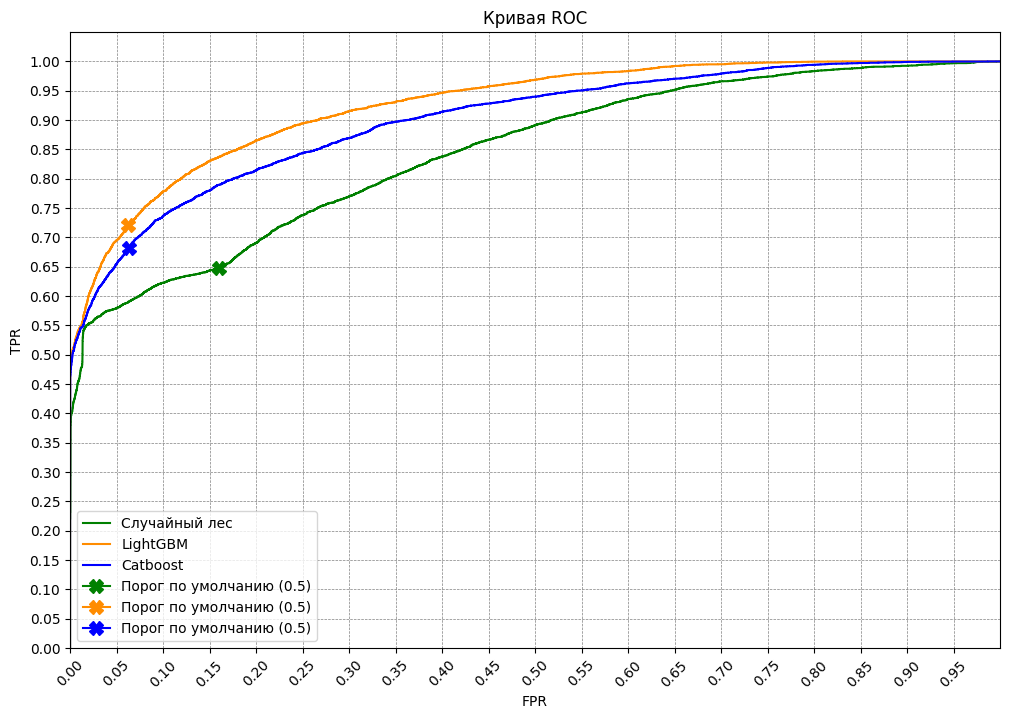

In [215]:
# Построим кривую ROC и отметим точку, соответствующую обученной модели
# Модель на основе случайного леса
probabilities_forest = gs_rf.predict_proba(train[X])
probabilities_one_forest = probabilities_forest[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(train[y], probabilities_one_forest)
# Модель из библиотеки LightGBM
probabilities_lgbm = grid_lgbm.predict_proba(X_train_LGBM)
probabilities_one_lgbm = probabilities_lgbm[:, 1]
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(train[y], probabilities_one_lgbm)
# Модель из библитоки catboost
probabilities_cb = grid_cb.predict_proba(train[X])
probabilities_one_cb = probabilities_cb[:, 1]
fpr_cb, tpr_cb, thresholds_cb = roc_curve(train[y], probabilities_one_cb)
# Нейронная сеть
#probabilities_net = gs_net_3.best_estimator_.predict_proba(train[X])
#probabilities_one_net = probabilities_net[:, 1]
#fpr_net, tpr_net, thresholds_net = roc_curve(train[y], probabilities_one_net)

# Кривые ROC
plt.figure(figsize=(12, 8))
plt.step(fpr_rf, tpr_rf, where='post', label='Случайный лес', color='green')
plt.step(fpr_lgbm, tpr_lgbm, where='post', label='LightGBM', color='darkorange')
plt.step(fpr_cb, tpr_cb, where='post', label='Catboost', color='blue')
#plt.step(fpr_net, tpr_net, where='post', label='Нейронная сеть', color='red')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.xticks(np.arange(0, 1.0, step=0.05), rotation=45)
plt.yticks(np.arange(0, 1.05, step=0.05))
plt.grid(color='gray', linewidth=0.5, linestyle='--')
plt.title('Кривая ROC')
# Точки обученных моделей на кривой
# Модель на основе случайного леса
plt.plot(
    fpr_rf[thresholds_rf == thresholds_rf[thresholds_rf >= 0.5][-1]],
    tpr_rf[thresholds_rf == thresholds_rf[thresholds_rf >= 0.5][-1]],
    color='green',
    marker='X',
    markersize=10,
    label='Порог по умолчанию (0.5)'
)
# Модель из библиотеки LightGBM
plt.plot(
    fpr_lgbm[thresholds_lgbm == thresholds_lgbm[thresholds_lgbm >= 0.5][-1]],
    tpr_lgbm[thresholds_lgbm == thresholds_lgbm[thresholds_lgbm >= 0.5][-1]],
    color='darkorange',
    marker='X',
    markersize=10,
    label='Порог по умолчанию (0.5)'
)
# Модель из библитоки catboost
plt.plot(
    fpr_cb[thresholds_cb == thresholds_cb[thresholds_cb >= 0.5][-1]],
    tpr_cb[thresholds_cb == thresholds_cb[thresholds_cb >= 0.5][-1]],
    color='blue',
    marker='X',
    markersize=10,
    label='Порог по умолчанию (0.5)'
)

# Нейронная сеть
#plt.plot(
#    fpr_net[thresholds_net == thresholds_net[thresholds_net >= 0.5][-1]],
#    tpr_net[thresholds_net == thresholds_net[thresholds_net >= 0.5][-1]],
#    color='red',
#    marker='X',
#    markersize=10,
#    label='Порог по умолчанию (0.5)'
#)
# plt.plot(fpr[thresholds==thresholds[tpr>=0.7][0]],
#    tpr[thresholds==thresholds[tpr>=0.7][0]], color='green', marker='o', markersize=8, label='Изменённый порог')
plt.legend()
plt.show()

По результатам обучения выбираем модель на основе полносвязной нейронной сети.

## Тестирование модели

In [103]:
# Подберём порог таким образом, чтоб точка на ROC была ближе всего к точке TPR=1 и FPR=0
min_distance = 2**0.5
best_tpr = 0
best_fpr = 1
best_th = 0
for th in np.arange(0,1,0.0001):
    tpr = tpr_net[thresholds_net == thresholds_net[thresholds_net >= th][-1]]
    fpr = fpr_net[thresholds_net == thresholds_net[thresholds_net >= th][-1]]
    distance = ((1 - tpr)**2 + fpr**2)**0.5
    if distance < min_distance:
        best_th = th
        best_tpr = tpr
        best_fpr = fpr
        min_distance = distance
print(f'best_th {best_th} best_tpr {best_tpr} best_fpr {best_fpr}')

best_th 0.2617 best_tpr [0.82167043] best_fpr [0.26631259]


In [106]:
# Проверим метрики наилучшей модели на тестовой выборке
roc_auc = roc_auc_score(test[y], probabilities_one_net)
print(f'test_auc_roc: {roc_auc: .2f}')

test_predicted = (probabilities_one_net>best_th).astype('int')

accuracy = accuracy_score(test[y], test_predicted)
print(f'test_accuracy: {accuracy: .2f}')

test_auc_roc:  0.85
test_accuracy:  0.75


Удалось достичь значение метрики AUC ROC 0,85. Рассмотрим матрицу ошибок.

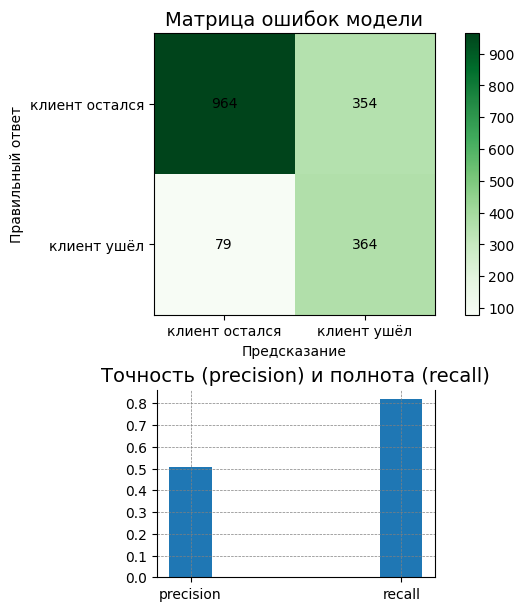

In [107]:
fig = plt.figure(figsize=(8, 6),
                       constrained_layout=True)
gs = fig.add_gridspec(5, 5)
f_ax1 = fig.add_subplot(gs[:3,:4])
f_ax2 = fig.add_subplot(gs[3:, 2:4])
f_ax1.set_title('Матрица ошибок модели', fontsize=14)
f_ax2.set_title('Точность (precision) и полнота (recall)', fontsize=14)

# Отобразим результаты модели
cm = confusion_matrix(test[y], test_predicted)
f_ax2.grid(color='gray', linewidth = 0.5, linestyle = '--')
f_ax2.set_yticks(np.arange(0, 1, 0.1))
xlabs = ['клиент остался', 'клиент ушёл']
ylabs = xlabs
f_ax1.set_yticks(np.arange(len(ylabs)), labels = ylabs)
f_ax1.set_xticks(np.arange(len(xlabs)), labels = xlabs)
f_ax1.set_ylabel('Правильный ответ')
f_ax1.set_xlabel('Предсказание')
precision = cm[1, 1]/sum(cm[:, 1])
recall = cm[1, 1]/sum(cm[1, :])
for i in range(len(xlabs)):
    for j in range(len(ylabs)):
        text = f_ax1.text(j, i, cm[i, j],
        ha = "center", va = "center", color = "black")
im = f_ax1.imshow(cm, cmap = 'Greens')
cbar = f_ax1.figure.colorbar(im, ax = f_ax1, use_gridspec=True)
f_ax2.spines['top'].set_visible(False)
f_ax2.set_xticks([0, 1], labels = ['precision','recall'])
f_ax2.bar([0, 1], [precision, recall], align='center', width=0.2)
plt.show()

Видим, что модель приблизительно в половине случаев ошибается, тем не менее, 80% отточных клиентов ей удаётся распознать. Считаем такой результат приемлемым. Проанализируем важность признаков

In [108]:
best_net = gs_net_3.best_estimator_.steps[2][1].module_

In [109]:
try:
    feature_names = list(
        col_transformer_net.named_transformers_['onehotencoder'].get_feature_names_out()
    ) + list(
        col_transformer_net.named_transformers_['minmaxscaler'].get_feature_names_out()
    )
except:
    feature_names = list(
        col_transformer_net.transformers_[0][1].get_feature_names()
    ) + list(
        num_features
    )
feature_names

['SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'Type_One year',
 'Type_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'OnlineBackup_Yes',
 'DeviceProtection_Yes',
 'TechSupport_Yes',
 'StreamingTV_Yes',
 'StreamingMovies_Yes',
 'MultipleLines_Yes',
 'total_charges_cat_clients_1000-3000',
 'total_charges_cat_clients_3000-4000',
 'total_charges_cat_clients_4000',
 'contract_duration_cat_clients_30-80',
 'contract_duration_cat_clients_450-540',
 'contract_duration_cat_clients_540',
 'contract_duration_cat_clients_80-450',
 'MonthlyCharges']

In [110]:
# Просуммируем веса для входов нейронной сети
feature_names = list(
    col_transformer_net.named_transformers_['onehotencoder'].get_feature_names_out()
) + list(
    col_transformer_net.named_transformers_['minmaxscaler'].get_feature_names_out()
)
weight_sum = pd.Series(best_net.fc1.weight.sum(axis=0).cpu().detach().numpy(),
                       index = feature_names)
weight_sum = weight_sum.sort_values()
weight_sum

InternetService_Fiber optic             -2.109434
TechSupport_Yes                          0.364627
PaperlessBilling_Yes                     0.402893
PaymentMethod_Mailed check               0.420384
contract_duration_cat_clients_450-540    0.455401
StreamingTV_Yes                          0.537909
SeniorCitizen_Yes                        0.622062
PaymentMethod_Electronic check           0.657883
contract_duration_cat_clients_30-80      0.885372
DeviceProtection_Yes                     0.944385
MultipleLines_Yes                        0.950705
StreamingMovies_Yes                      1.115822
OnlineBackup_Yes                         1.246349
MonthlyCharges                           1.284143
contract_duration_cat_clients_540        1.463020
Partner_Yes                              2.064137
PaymentMethod_Credit card (automatic)    2.068570
InternetService_No                       2.241148
OnlineSecurity_Yes                       2.496670
Type_One year                            2.497075


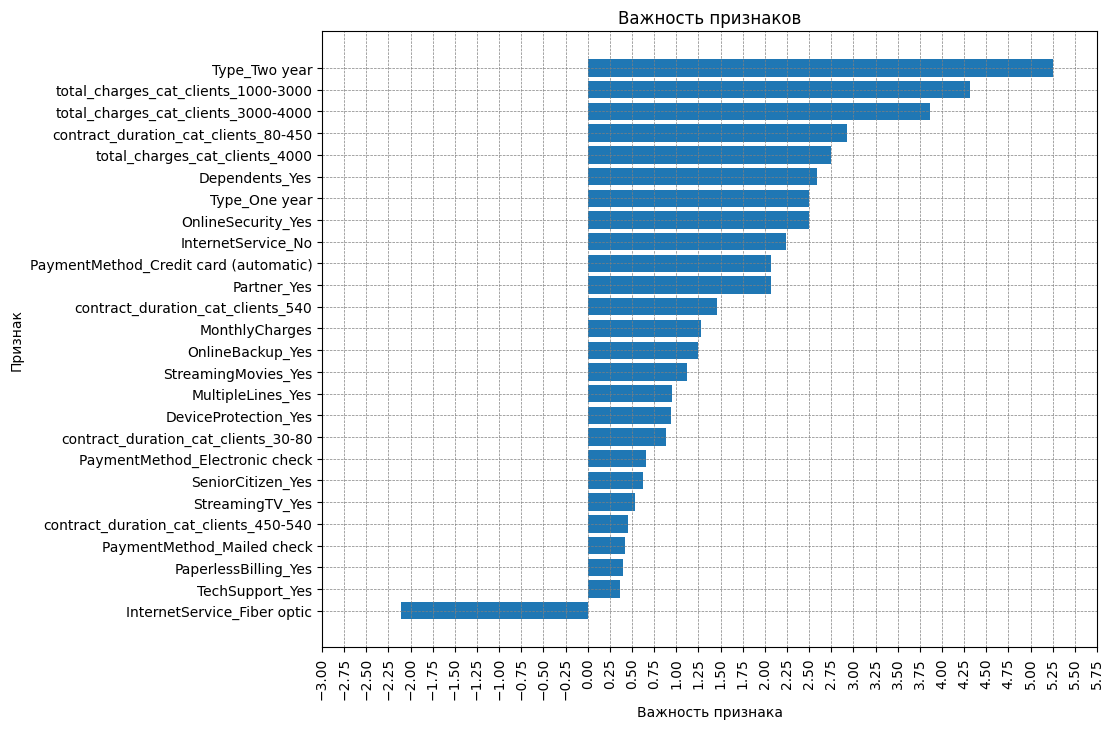

In [115]:
# Построим график
plt.figure(figsize=(10, 8))
plt.title('Важность признаков')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.xlim([-0.6, 3])
plt.xticks(np.arange(-3, 6, step=0.25), rotation=90)
plt.grid(color='gray', linewidth = 0.5, linestyle = '--')
plt.barh(y=weight_sum.index, width=weight_sum)
plt.show()

In [112]:
# Просуммируем веса для исходных наименований признаков
importances = pd.Series(np.zeros(len(train[X].columns)), index=train[X].columns)

In [113]:
# Теперь сложим веса с учётом исходных наименований признаков до кодировки
for feature in train[X].columns:
    for net_input in weight_sum.index:
        if feature in net_input:
            importances[feature] += weight_sum[net_input]
importances = importances.sort_values()
importances

InternetService           0.131714
TechSupport               0.364627
PaperlessBilling          0.402893
StreamingTV               0.537909
SeniorCitizen             0.622062
DeviceProtection          0.944385
MultipleLines             0.950705
StreamingMovies           1.115822
OnlineBackup              1.246349
MonthlyCharges            1.284143
Partner                   2.064137
OnlineSecurity            2.496670
Dependents                2.591921
PaymentMethod             3.146838
contract_duration_cat     5.729905
Type                      7.750929
total_charges_cat        10.922388
dtype: float64

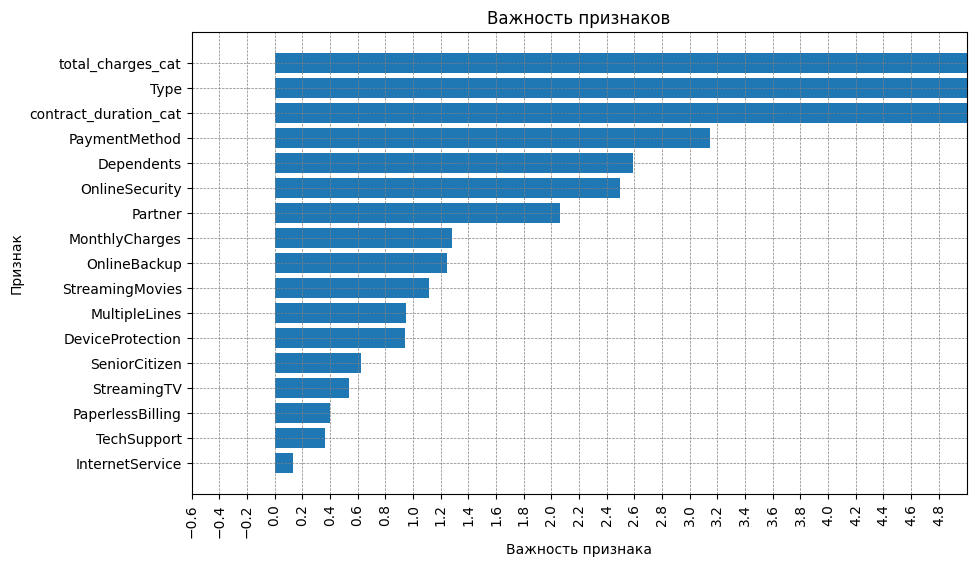

In [114]:
# Построим график
plt.figure(figsize=(10, 6))
plt.title('Важность признаков')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.xlim([-0.6, 5])
plt.xticks(np.arange(-0.6, 5, step=0.2), rotation=90)
plt.grid(color='gray', linewidth = 0.5, linestyle = '--')
plt.barh(y=importances.index, width=importances)
plt.show()

Наиболее "важные" признаки:
- `total_charges_cat` — категория клиента по общим расходам;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `contract_duration_cat` - категория клиента в зависимости от длительности контракта;
- `PaymentMethod` - тип платежа;
- `Dependents` - наличие или отсутствие детей.

По графикам, полученным в разделе [3.3](#Анализ-данных-объединённой-таблицы), доля ушедших клинентов при различных значениях указанных признаков меняется, т.е. противоречий в полученных результатах не наблюдается. При этом признаки в верхней части таблицы `Type_Two year`, `total_charges_cat_clients_1000-3000`, `total_charges_cat_clients_3000-4000`,
`total_charges_cat_clients_80-450`,
`total_charges_cat_clients_4000` соответствуют больше лояльным клиентам, которые вероятнее всего не уйдут.

## Выводы

В ходе работы выполнено:
- подключение к базе данных и первичный анализ таблиц,
- анализ данных в таблицах,
- объединение таблиц, анализ и предобработка признаков в объединённой таблице,
- выбор факторов для моделей машинного обучения,
- проработка нескольких моделей (на основе случайного леса, модели градиентного бустинга из библиотек LightGBM и Catboost, полносвязная нейронная сеть) выбрана лучшая,
- лучшая модель протестирована,
- проведён анализ важности признаков.  
Рекомендации заказчику: с точки зрения оттока следует обрать внимание на клиентов, у которых оплата помесячно, суммарные затраты меньше 1000, длительность контракта не превышает 90 дней или превышает 540 дней.